In [1]:
# Step 1: Import Necessary Libraries
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import image, plotting, masking, datasets
from nilearn.input_data import NiftiMasker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [2]:
import os

def get_bold_file_paths(base_dir):
    control_subjects = []
    non_dyslexic_subjects = []
    control_ids = {11, 12, 13, 18, 19, 23, 24, 25, 26, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 41}
    
    for sub_num in range(1, 43):  # Looping from sub-01 to sub-42
        sub_folder = f"sub-{sub_num:02d}"  # Format to ensure two-digit numbering
        #func_path = os.path.join(base_dir, sub_folder, "func")
        func_path = os.path.join(base_dir, sub_folder)
        
        if os.path.exists(func_path):
            for file in os.listdir(func_path):
                if file.endswith(("task-morphosem_run-01_bold.nii.gz","task-morphosem_run-02_bold.nii.gz","task-morphosem_run-03_bold.nii.gz","task-morphosem_run-04_bold.nii.gz")):
                    file_path = os.path.join(func_path, file)
                    if sub_num in control_ids:
                        control_subjects.append(file_path)
                    else:
                        non_dyslexic_subjects.append(file_path)
    
    return control_subjects, non_dyslexic_subjects

# Set the base directory
#base_directory = r"D:\project_7th_sem\ds004786-download"
base_directory = r"D:\myResearch\Dataset01_MorphoSem"

# Get the list of file paths
control_subjects, non_dyslexic_subjects = get_bold_file_paths(base_directory)

# Print the lists
print("Control Subjects:")
for i,path in enumerate(control_subjects):
    print(path)

print("\nNon-Dyslexic Subjects:")
for j,path in enumerate(non_dyslexic_subjects):
    print(path)

print (i)
print (j)

print(len(control_subjects),len(non_dyslexic_subjects))

Control Subjects:
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-04_bold.nii.g

[get_dataset_dir] Dataset found in C:\Users\utpal\nilearn_data\fsl

0: Background
1: Frontal Pole
2: Insular Cortex
3: Superior Frontal Gyrus
4: Middle Frontal Gyrus
5: Inferior Frontal Gyrus, pars triangularis
6: Inferior Frontal Gyrus, pars opercularis
7: Precentral Gyrus
8: Temporal Pole
9: Superior Temporal Gyrus, anterior division
10: Superior Temporal Gyrus, posterior division
11: Middle Temporal Gyrus, anterior division
12: Middle Temporal Gyrus, posterior division
13: Middle Temporal Gyrus, temporooccipital part
14: Inferior Temporal Gyrus, anterior division
15: Inferior Temporal Gyrus, posterior division
16: Inferior Temporal Gyrus, temporooccipital part
17: Postcentral Gyrus
18: Superior Parietal Lobule
19: Supramarginal Gyrus, anterior division
20: Supramarginal Gyrus, posterior division
21: Angular Gyrus
22: Lateral Occipital Cortex, superior division
23: Lateral Occipital Cortex, inferior division
24: Intracalcarine Cortex
25: Frontal Medial Cortex
26: Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
27: Subcallosal Cort

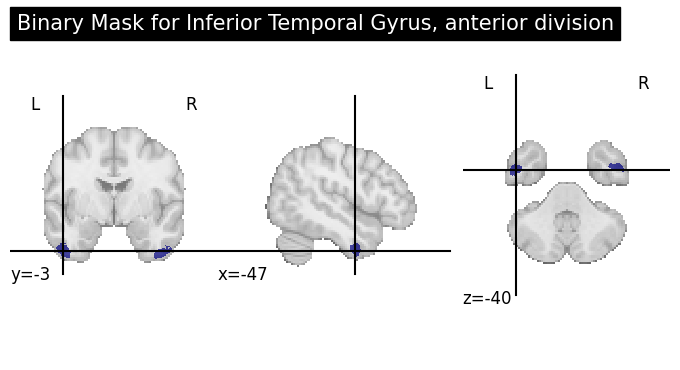

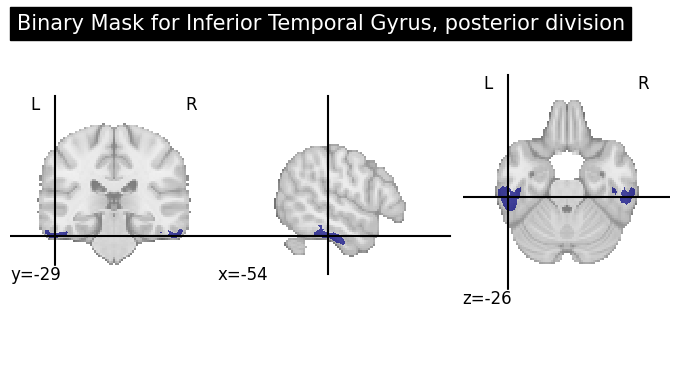

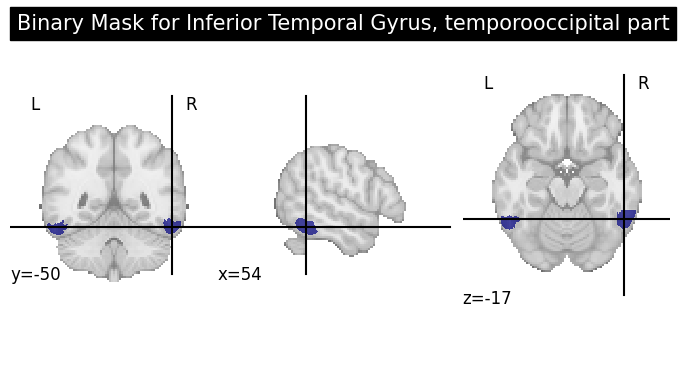

In [3]:
# Step 2: Load the Harvard-Oxford atlas and select a specific region
from nilearn.image import math_img

# Load the Harvard-Oxford cortical atlas (probabilistic map)
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')
atlas_img = atlas['maps']
atlas_labels = atlas['labels']

# Print available region labels to confirm the correct region index
for idx, label in enumerate(atlas_labels):
    print(f"{idx}: {label}")

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars triangularis)
region_name1 = "Inferior Temporal Gyrus, anterior division"  # Region of Interest
region_idx1 = atlas_labels.index(region_name1)  # Find index for Inferior Frontal Gyrus, pars triangularis
# Create a binary mask for the selected region
binary_mask1 = math_img(f"img == {region_idx1}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask1, title=f"Binary Mask for {region_name1}", display_mode='ortho')
plotting.show()

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars opercularis)
region_name2 = "Inferior Temporal Gyrus, posterior division"  # Region of Interest
region_idx2 = atlas_labels.index(region_name2)  # Find index for Inferior Frontal Gyrus, pars opercularis 
# Create a binary mask for the selected region
binary_mask2 = math_img(f"img == {region_idx2}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask2, title=f"Binary Mask for {region_name2}", display_mode='ortho')
plotting.show()

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars opercularis)
region_name3 = "Inferior Temporal Gyrus, temporooccipital part"  # Region of Interest
region_idx3 = atlas_labels.index(region_name3)  # Find index for Inferior Frontal Gyrus, pars opercularis 
# Create a binary mask for the selected region
binary_mask3 = math_img(f"img == {region_idx3}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask3, title=f"Binary Mask for {region_name3}", display_mode='ortho')
plotting.show()

## Loading a single ROI **(MEAN)**:- 1) Inferior Temporal Gyrus-Anterior Division
#### Then performing the experiments.

In [4]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd1 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
#print(control_mean_data1[79][2376])

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data1, non_dyslexic_mean_data1])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data1) + [0] * len(non_dyslexic_mean_data1))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(1665,)
(1665,)
(160, 1665)
(160,)


Training Accuracy on Inferior Temporal Gyrus- anterior division (Logistic Regression): 98.44%
Testing Accuracy on Inferior Temporal Gyrus- anterior division (Logistic Regression): 40.62%

Classification Report for Testing Data on Inferior Temporal Gyrus- anterior division (Logistic Regression):
              precision    recall  f1-score   support

           0       0.36      0.25      0.30        16
           1       0.43      0.56      0.49        16

    accuracy                           0.41        32
   macro avg       0.40      0.41      0.39        32
weighted avg       0.40      0.41      0.39        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (Logistic Regression): 0.41


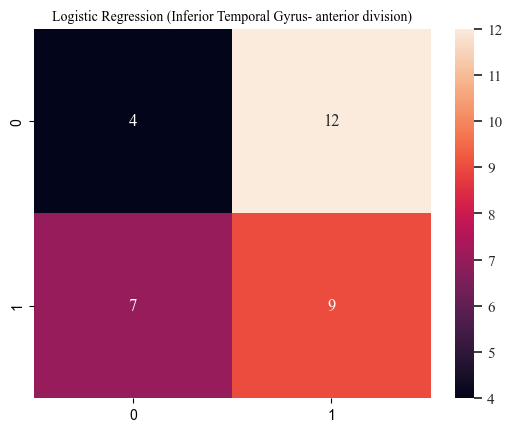

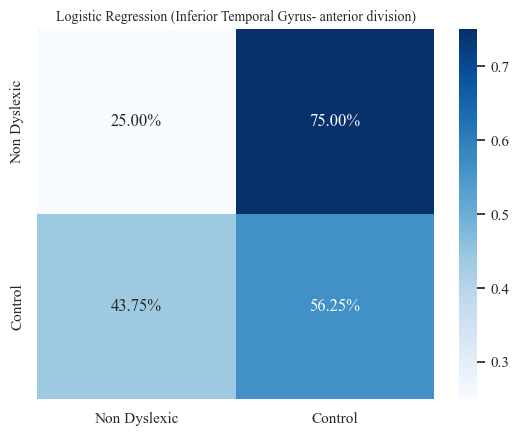

In [5]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Inferior Temporal Gyrus- anterior division (Logistic Regression): {log_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- anterior division (Logistic Regression): {log_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- anterior division (Logistic Regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (Logistic Regression): {log_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('Logistic Regression (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(Log_Reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic Regression (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(Log_Reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- anterior division (Support Vector Machine): 72.66%
Testing Accuracy on Inferior Temporal Gyrus- anterior division (Support Vector Machine): 56.25%

Classification Report for Testing Data on Inferior Temporal Gyrus- anterior division (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.55      0.75      0.63        16
           1       0.60      0.38      0.46        16

    accuracy                           0.56        32
   macro avg       0.57      0.56      0.55        32
weighted avg       0.57      0.56      0.55        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (Support Vector Machine): 0.56


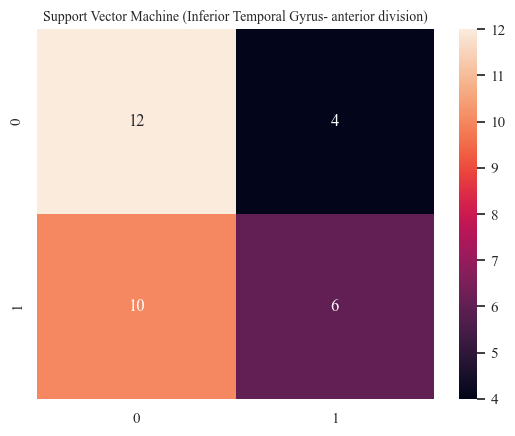

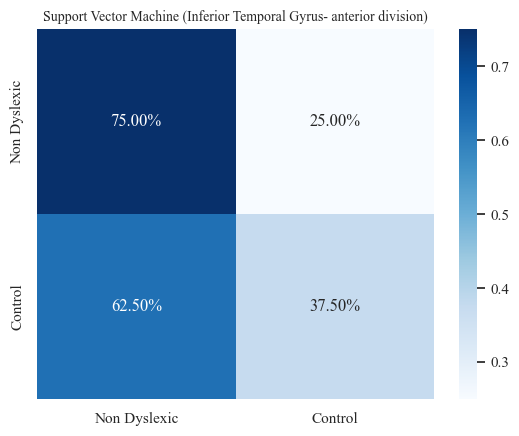

In [6]:
###### SVM model

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Calculate training and testing accuracy
svm_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- anterior division (Support Vector Machine): {svm_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- anterior division (Support Vector Machine): {svm_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- anterior division (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (Support Vector Machine): {svm_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- anterior division (k-nearest neighbors): 88.28%
Testing Accuracy on Inferior Temporal Gyrus- anterior division (k-nearest neighbors): 53.12%

Classification Report for Testing Data on Inferior Temporal Gyrus- anterior division (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.56      0.31      0.40        16
           1       0.52      0.75      0.62        16

    accuracy                           0.53        32
   macro avg       0.54      0.53      0.51        32
weighted avg       0.54      0.53      0.51        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (k-nearest neighbors): 0.53


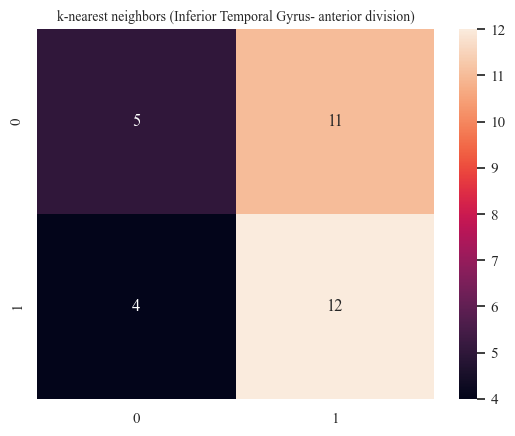

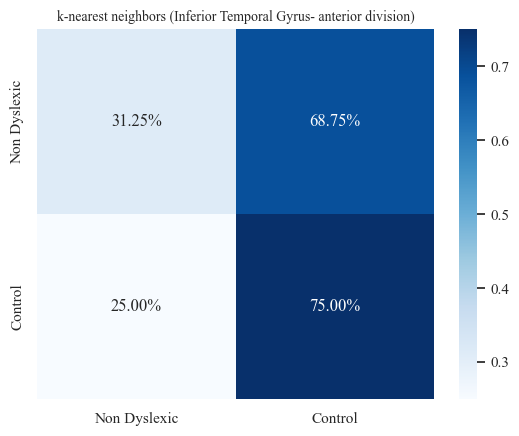

In [7]:
##### KNN model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- anterior division (k-nearest neighbors): {knn_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- anterior division (k-nearest neighbors): {knn_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- anterior division (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (k-nearest neighbors): {knn_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/3-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(KNN)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 1665) Label:- (128,)
Total Testing set:-  Dataset:- (32, 1665) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         852,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 926,977 (3.54 MB)

 Trainable params: 926,977 (3.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5208 - loss: 0.8060
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8594 - loss: 0.4520
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9375 - loss: 0.3694
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9844 - loss: 0.3101
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9844 - loss: 0.2551
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9896 - loss: 0.2127
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9844 - loss: 0.1849
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9792 - loss: 0.1498
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9792 - loss: 0.1187
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9896 - loss: 0.0800
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9844 - loss: 0.0668
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9844 - loss: 0.0516
E

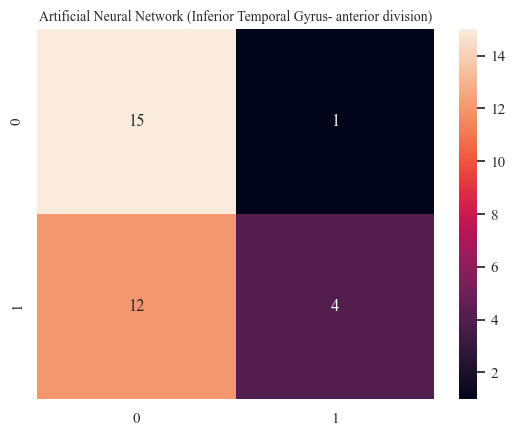

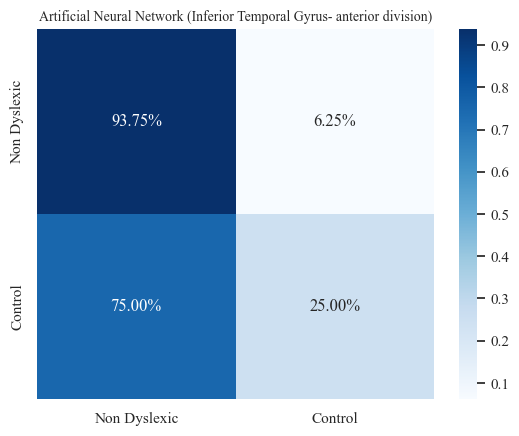

In [8]:
###### ANN Model

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
ann_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- anterior division (Artificial Neural Network): {ann_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- anterior division (Artificial Neural Network): {ann_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- anterior division (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (Artificial Neural Network): {ann_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- anterior division (Random Forest): 100.00%
Testing Accuracy on Inferior Temporal Gyrus- anterior division (Random Forest): 71.88%

Classification Report for Testing Data on Inferior Temporal Gyrus- anterior division (Random Forest):
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        16
           1       0.73      0.69      0.71        16

    accuracy                           0.72        32
   macro avg       0.72      0.72      0.72        32
weighted avg       0.72      0.72      0.72        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (Random Forest): 0.72


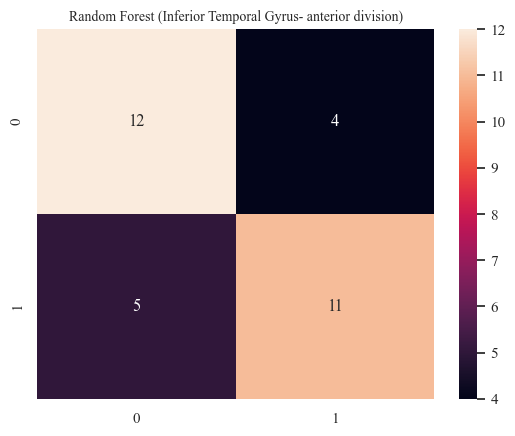

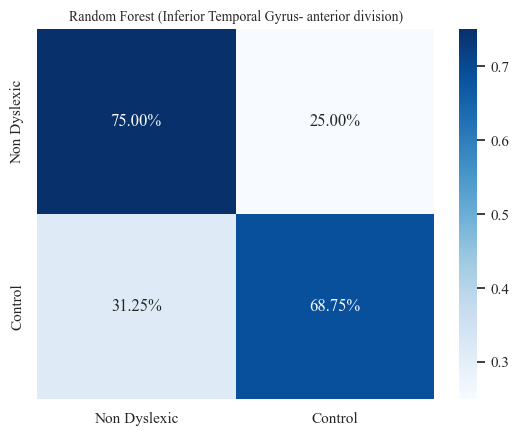

In [9]:
##### Random Forest model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Inferior Temporal Gyrus- anterior division (Random Forest): {rf_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- anterior division (Random Forest): {rf_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- anterior division (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (Random Forest): {rf_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('Random Forest (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(Rand_Forst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(Rand_Forst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- anterior division (XGBoost): 100.00%
Testing Accuracy on Inferior Temporal Gyrus- anterior division (XGBoost): 68.75%

Classification Report for Testing Data on Inferior Temporal Gyrus- anterior division (XGBoost):
              precision    recall  f1-score   support

           0       0.75      0.56      0.64        16
           1       0.65      0.81      0.72        16

    accuracy                           0.69        32
   macro avg       0.70      0.69      0.68        32
weighted avg       0.70      0.69      0.68        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (XGBoost): 0.69


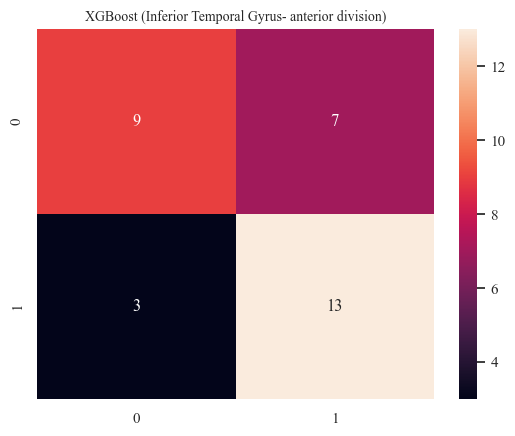

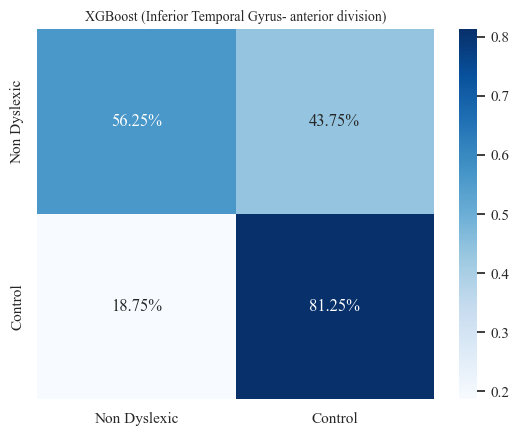

In [10]:
##### XGBoost (eXtreme Gradient Boosting) model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Inferior Temporal Gyrus- anterior division (XGBoost): {xgb_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- anterior division (XGBoost): {xgb_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- anterior division (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- anterior division (XGBoost): {xgb_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('XGBoost (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Inferior Temporal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_1(XGBst)_percent.png", dpi=600)
plt.show()

In [11]:
mean1=[]
mean1.append([round(log_mean_prf_ROI1[0][0],2),round(log_mean_prf_ROI1[1][0],2),round(log_mean_prf_ROI1[2][0],2),round(log_mean_test_accuracy_ROI1,2),round(log_mean_roc_ROI1,2)])
mean1.append([round(log_mean_prf_ROI1[0][1],2),round(log_mean_prf_ROI1[1][1],2),round(log_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(svm_mean_prf_ROI1[0][0],2),round(svm_mean_prf_ROI1[1][0],2),round(svm_mean_prf_ROI1[2][0],2),round(svm_mean_test_accuracy_ROI1,2),round(svm_mean_roc_ROI1,2)])
mean1.append([round(svm_mean_prf_ROI1[0][1],2),round(svm_mean_prf_ROI1[1][1],2),round(svm_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(knn_mean_prf_ROI1[0][0],2),round(knn_mean_prf_ROI1[1][0],2),round(knn_mean_prf_ROI1[2][0],2),round(knn_mean_test_accuracy_ROI1,2),round(knn_mean_roc_ROI1,2)])
mean1.append([round(knn_mean_prf_ROI1[0][1],2),round(knn_mean_prf_ROI1[1][1],2),round(knn_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(ann_mean_prf_ROI1[0][0],2),round(ann_mean_prf_ROI1[1][0],2),round(ann_mean_prf_ROI1[2][0],2),round(ann_mean_test_accuracy_ROI1,2),round(ann_mean_roc_ROI1,2)])
mean1.append([round(ann_mean_prf_ROI1[0][1],2),round(ann_mean_prf_ROI1[1][1],2),round(ann_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(rf_mean_prf_ROI1[0][0],2),round(rf_mean_prf_ROI1[1][0],2),round(rf_mean_prf_ROI1[2][0],2),round(rf_mean_test_accuracy_ROI1,2),round(rf_mean_roc_ROI1,2)])
mean1.append([round(rf_mean_prf_ROI1[0][1],2),round(rf_mean_prf_ROI1[1][1],2),round(rf_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(xgb_mean_prf_ROI1[0][0],2),round(xgb_mean_prf_ROI1[1][0],2),round(xgb_mean_prf_ROI1[2][0],2),round(xgb_mean_test_accuracy_ROI1,2),round(xgb_mean_roc_ROI1,2)])
mean1.append([round(xgb_mean_prf_ROI1[0][1],2),round(xgb_mean_prf_ROI1[1][1],2),round(xgb_mean_prf_ROI1[2][1],2),'',''])

df1 = pd.DataFrame(mean1,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
#df=df.style.set_sticky(axis="index")
df1=df1.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
display(df1)
df1.to_excel('../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Table_Mean_ROI_1_Inferior_Temporal_Gyrus.xlsx', engine='openpyxl')


## Loading a single ROI **(MEAN)**:- 2. Inferior Temporal Gyrus-Posterior Division
#### Then performing the experiments.

In [12]:
####Loading the saved dataset in np format.
cmd2 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_posterior_division.npz")
ndmd2 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data2, non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data2) + [0] * len(non_dyslexic_mean_data2))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(4262,)
(4262,)
(160, 4262)
(160,)


Training Accuracy on Inferior Temporal Gyrus- posterior division (Logistic regression): 100.00%
Testing Accuracy on Inferior Temporal Gyrus- posterior division (Logistic regression): 43.75%

Classification Report for Testing Data on Inferior Temporal Gyrus- posterior division (Logistic regression):
              precision    recall  f1-score   support

           0       0.40      0.25      0.31        16
           1       0.45      0.62      0.53        16

    accuracy                           0.44        32
   macro avg       0.43      0.44      0.42        32
weighted avg       0.43      0.44      0.42        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (Logistic Regression): 0.44


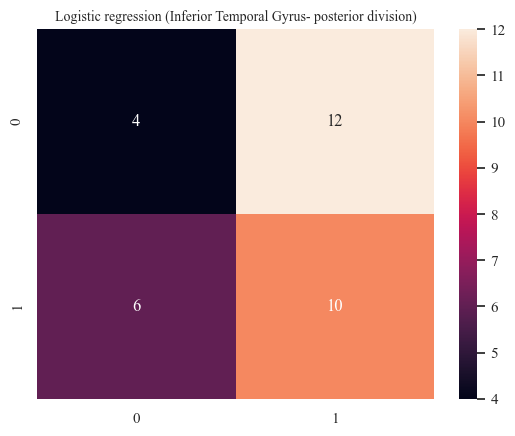

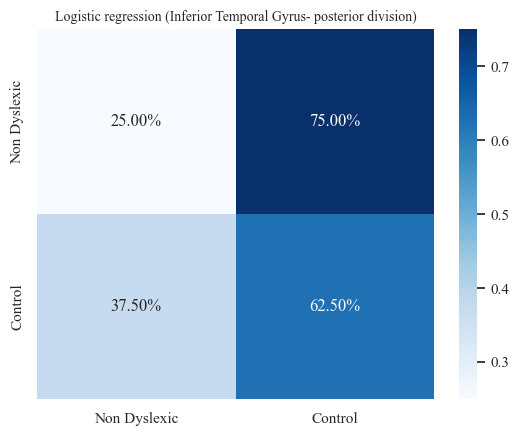

In [13]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- posterior division (Logistic regression): {log_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- posterior division (Logistic regression): {log_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- posterior division (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (Logistic Regression): {log_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- posterior division (Support Vector Machine): 68.75%
Testing Accuracy on Inferior Temporal Gyrus- posterior division (Support Vector Machine): 65.62%

Classification Report for Testing Data on Inferior Temporal Gyrus- posterior division (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.59      1.00      0.74        16
           1       1.00      0.31      0.48        16

    accuracy                           0.66        32
   macro avg       0.80      0.66      0.61        32
weighted avg       0.80      0.66      0.61        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (Support Vector Machine): 0.66


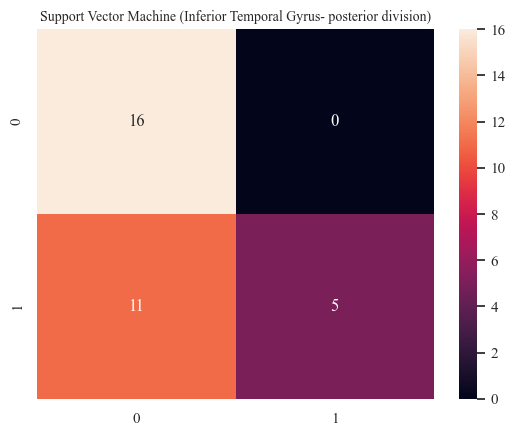

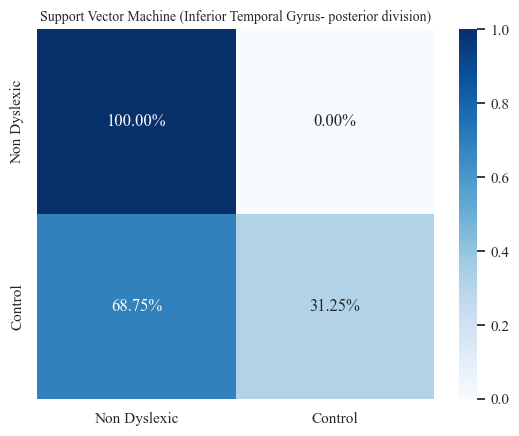

In [14]:
##### SVM model

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- posterior division (Support Vector Machine): {svm_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- posterior division (Support Vector Machine): {svm_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- posterior division (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (Support Vector Machine): {svm_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- posterior division (k-nearest neighbors): 56.25%
Testing Accuracy on Inferior Temporal Gyrus- posterior division (k-nearest neighbors): 46.88%

Classification Report for Testing Data on Inferior Temporal Gyrus- posterior division (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.40      0.12      0.19        16
           1       0.48      0.81      0.60        16

    accuracy                           0.47        32
   macro avg       0.44      0.47      0.40        32
weighted avg       0.44      0.47      0.40        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (k-nearest neighbors): 0.47


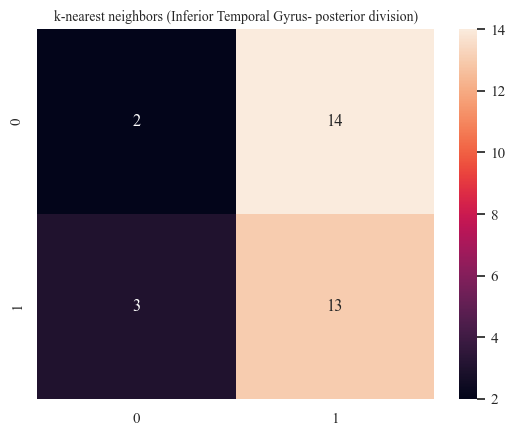

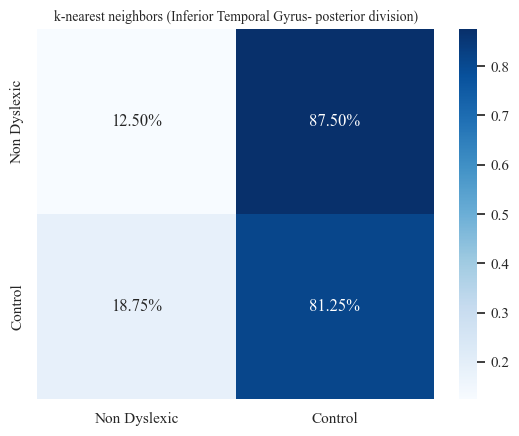

In [15]:
##### KNN model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- posterior division (k-nearest neighbors): {knn_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- posterior division (k-nearest neighbors): {knn_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- posterior division (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (k-nearest neighbors): {knn_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(KNN)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 4262) Label:- (128,)
Total Testing set:-  Dataset:- (32, 4262) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 512)                 │       2,182,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,256,641 (8.61 MB)

 Trainable params: 2,256,641 (8.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4740 - loss: 0.7138 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8177 - loss: 0.4151
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9531 - loss: 0.3490
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9115 - loss: 0.2842
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9740 - loss: 0.2462
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9688 - loss: 0.1953
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9792 - loss: 0.1568
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.0964
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.0620
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0390
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.0196
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0112


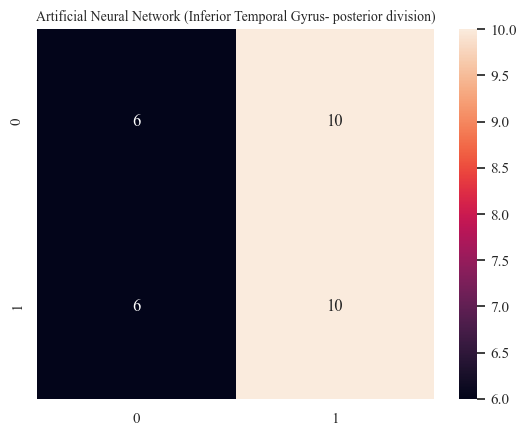

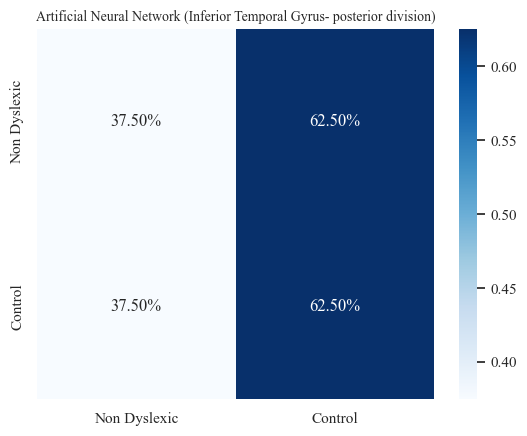

In [16]:
###### ANN Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
ann_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- posterior division (Artificial Neural Network): {ann_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- posterior division (Artificial Neural Network): {ann_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- posterior division (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))
ann_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (Artificial Neural Network): {ann_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- posterior division (Random Forest): 100.00%
Testing Accuracy on Inferior Temporal Gyrus- posterior division (Random Forest): 59.38%

Classification Report for Testing Data on Inferior Temporal Gyrus- posterior division (Random Forest):
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.59      0.62      0.61        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (Random Forest): 0.59


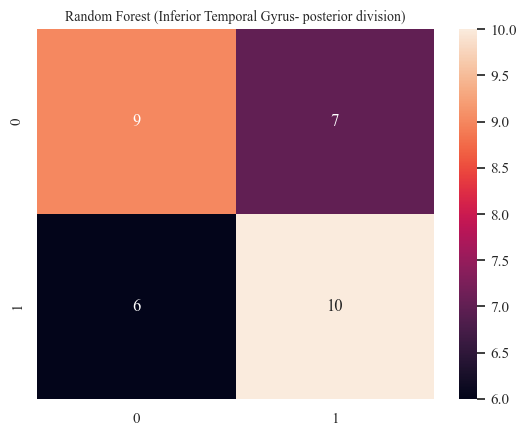

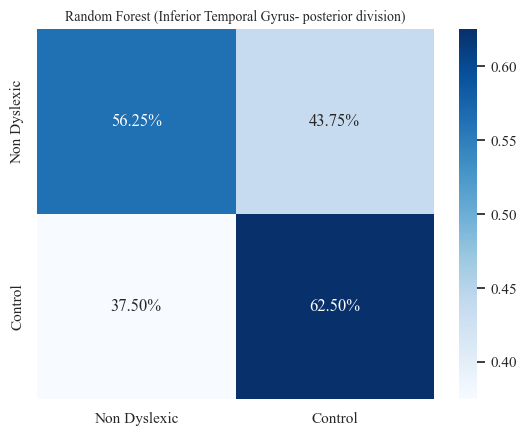

In [17]:
##### Random Forest model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- posterior division (Random Forest): {rf_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- posterior division (Random Forest): {rf_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- posterior division (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (Random Forest): {rf_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(Rand_Forst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(Rand_Forst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- posterior division (XGBoost): 100.00%
Testing Accuracy on Inferior Temporal Gyrus- posterior division (XGBoost): 46.88%

Classification Report for Testing Data on Inferior Temporal Gyrus- posterior division (XGBoost):
              precision    recall  f1-score   support

           0       0.46      0.38      0.41        16
           1       0.47      0.56      0.51        16

    accuracy                           0.47        32
   macro avg       0.47      0.47      0.46        32
weighted avg       0.47      0.47      0.46        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (XGBoost): 0.47


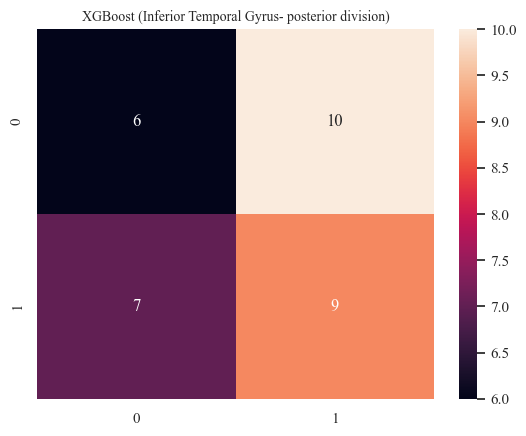

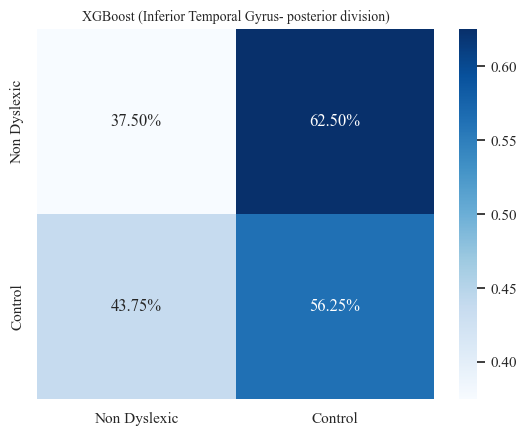

In [18]:
##### XGBoost (Extreme Gradient Boosting) model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- posterior division (XGBoost): {xgb_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- posterior division (XGBoost): {xgb_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- posterior division (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- posterior division (XGBoost): {xgb_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Inferior Temporal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_2(XGBst)_percent.png", dpi=600)
plt.show()

In [19]:
mean2=[]
mean2.append([round(log_mean_prf_ROI2[0][0],2),round(log_mean_prf_ROI2[1][0],2),round(log_mean_prf_ROI2[2][0],2),round(log_mean_test_accuracy_ROI2,2),round(log_mean_roc_ROI2,2)])
mean2.append([round(log_mean_prf_ROI2[0][1],2),round(log_mean_prf_ROI2[1][1],2),round(log_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(svm_mean_prf_ROI2[0][0],2),round(svm_mean_prf_ROI2[1][0],2),round(svm_mean_prf_ROI2[2][0],2),round(svm_mean_test_accuracy_ROI2,2),round(svm_mean_roc_ROI2,2)])
mean2.append([round(svm_mean_prf_ROI2[0][1],2),round(svm_mean_prf_ROI2[1][1],2),round(svm_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(knn_mean_prf_ROI2[0][0],2),round(knn_mean_prf_ROI2[1][0],2),round(knn_mean_prf_ROI2[2][0],2),round(knn_mean_test_accuracy_ROI2,2),round(knn_mean_roc_ROI2,2)])
mean2.append([round(knn_mean_prf_ROI2[0][1],2),round(knn_mean_prf_ROI2[1][1],2),round(knn_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(ann_mean_prf_ROI2[0][0],2),round(ann_mean_prf_ROI2[1][0],2),round(ann_mean_prf_ROI2[2][0],2),round(ann_mean_test_accuracy_ROI2,2),round(ann_mean_roc_ROI2,2)])
mean2.append([round(ann_mean_prf_ROI2[0][1],2),round(ann_mean_prf_ROI2[1][1],2),round(ann_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(rf_mean_prf_ROI2[0][0],2),round(rf_mean_prf_ROI2[1][0],2),round(rf_mean_prf_ROI2[2][0],2),round(rf_mean_test_accuracy_ROI2,2),round(rf_mean_roc_ROI2,2)])
mean2.append([round(rf_mean_prf_ROI2[0][1],2),round(rf_mean_prf_ROI2[1][1],2),round(rf_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(xgb_mean_prf_ROI2[0][0],2),round(xgb_mean_prf_ROI2[1][0],2),round(xgb_mean_prf_ROI2[2][0],2),round(xgb_mean_test_accuracy_ROI2,2),round(xgb_mean_roc_ROI2,2)])
mean2.append([round(xgb_mean_prf_ROI2[0][1],2),round(xgb_mean_prf_ROI2[1][1],2),round(xgb_mean_prf_ROI2[2][1],2),'',''])

df2 = pd.DataFrame(mean2,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
#df2=df2.style.set_sticky(axis="index")
df2.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
df2.style.set_caption("Table ROI_2 (Mean) Inferior Frontal Gyrus- posterior division")
display(df2)
df2.to_excel('../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Table_Mean_ROI_2_Inferior_Temporal_Gyrus.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.40    0.25      0.31     0.44   
                           Control            0.45    0.62      0.53            
Support Vector Machine     Non-Dyslexic       0.59    1.00      0.74     0.66   
                           Control            1.00    0.31      0.48            
k-nearest neighbors        Non-Dyslexic       0.40    0.12      0.19     0.47   
                           Control            0.48    0.81      0.60            
Artificial Neural Networks Non-Dyslexic       0.50    0.38      0.43      0.5   
                           Control            0.50    0.62      0.56            
Random Forest              Non-Dyslexic       0.60    0.56      0.58     0.59   
                           Control            0.59    0.62      0.61            
XGBoost                    Non-Dyslexic       0.46    0.38      0.41     0.47   
                           Control            0.47    0.56      0.51            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.44  
                           Control               
Support Vector Machine     Non-Dyslexic    0.66  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.47  
                           Control               
Artificial Neural Networks Non-Dyslexic     0.5  
                           Control               
Random Forest              Non-Dyslexic    0.59  
                           Control               
XGBoost                    Non-Dyslexic    0.47  
                           Control

## Loading a single ROI **(MEAN)**:- 3. Inferior Temporal Gyrus-Temporooccipital Part
#### Then performing the experiments.

In [20]:
####Loading the saved dataset in np format.
cmd3 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_temporooccipital_part.npz")
ndmd3 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data3 = cmd3["control_mean_data3"]
non_dyslexic_mean_data3=ndmd3["non_dyslexic_mean_data3"]
####
print(len(control_mean_data3))
print(len(non_dyslexic_mean_data3))
print(control_mean_data3[0].shape)
print(non_dyslexic_mean_data3[0].shape)

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data3, non_dyslexic_mean_data3])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data3) + [0] * len(non_dyslexic_mean_data3))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(4819,)
(4819,)
(160, 4819)
(160,)


Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (Logistic regression): 100.00%
Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (Logistic regression): 43.75%

Classification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Logistic regression):
              precision    recall  f1-score   support

           0       0.45      0.62      0.53        16
           1       0.40      0.25      0.31        16

    accuracy                           0.44        32
   macro avg       0.43      0.44      0.42        32
weighted avg       0.43      0.44      0.42        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Logistic Regression): 0.44


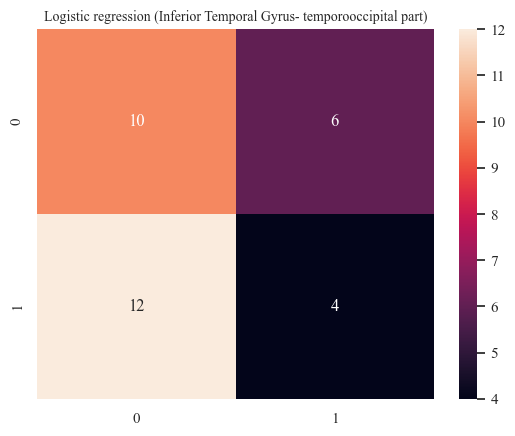

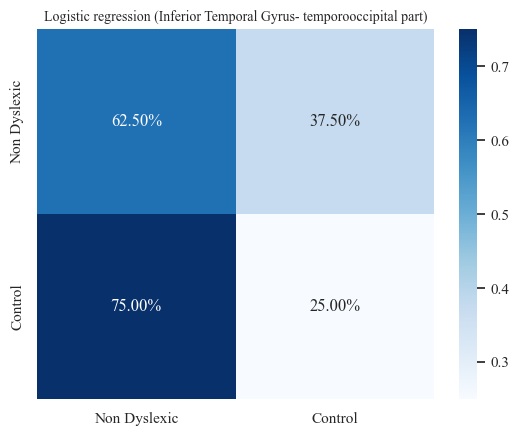

In [21]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (Logistic regression): {log_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (Logistic regression): {log_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Logistic Regression): {log_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (Support Vector Machine): 73.44%
Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (Support Vector Machine): 59.38%

Classification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.56      0.88      0.68        16
           1       0.71      0.31      0.43        16

    accuracy                           0.59        32
   macro avg       0.64      0.59      0.56        32
weighted avg       0.64      0.59      0.56        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Support Vector Machine): 0.59


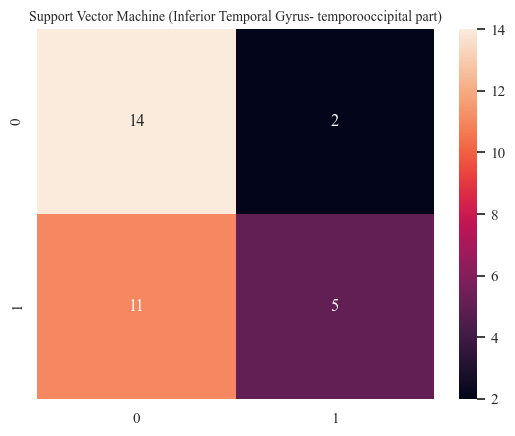

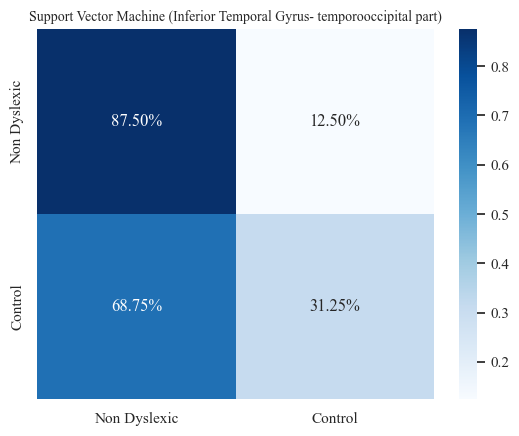

In [22]:
##### SVM model

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (Support Vector Machine): {svm_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (Support Vector Machine): {svm_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Support Vector Machine): {svm_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (k-nearest neighbors): 59.38%
Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (k-nearest neighbors): 56.25%

Classification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.54      0.94      0.68        16
           1       0.75      0.19      0.30        16

    accuracy                           0.56        32
   macro avg       0.64      0.56      0.49        32
weighted avg       0.64      0.56      0.49        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (k-nearest neighbors): 0.56


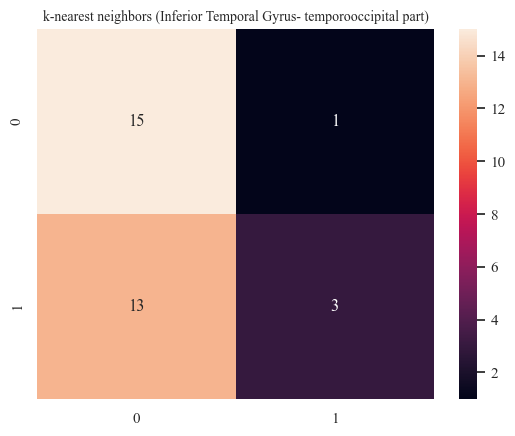

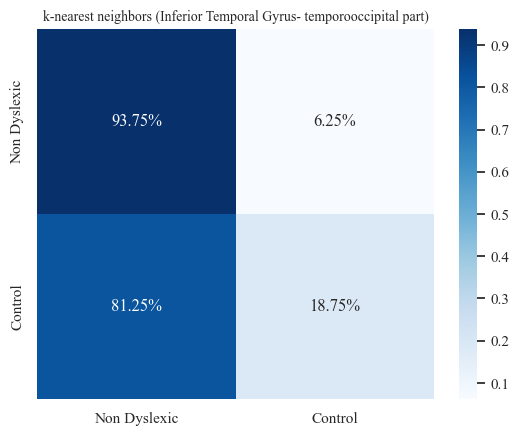

In [23]:
##### KNN model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (k-nearest neighbors): {knn_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (k-nearest neighbors): {knn_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (k-nearest neighbors): {knn_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(KNN)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 4819) Label:- (128,)
Total Testing set:-  Dataset:- (32, 4819) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 512)                 │       2,467,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,541,825 (9.70 MB)

 Trainable params: 2,541,825 (9.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5000 - loss: 0.7792 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9375 - loss: 0.3537
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9792 - loss: 0.2913
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.2216
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9896 - loss: 0.1618
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9948 - loss: 0.1072
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9896 - loss: 0.0675
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9948 - loss: 0.0383
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9896 - loss: 0.0243
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.0149
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.0069
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0062


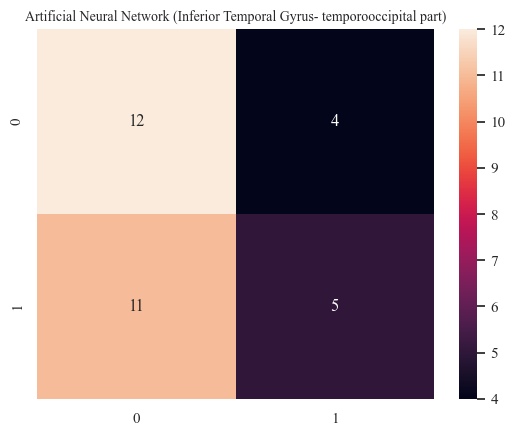

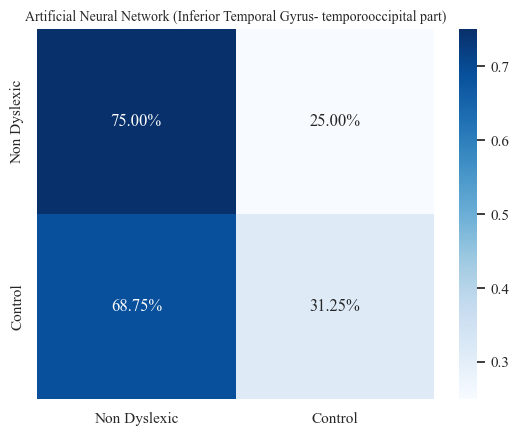

In [24]:
###### ANN Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
ann_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (Artificial Neural Network): {ann_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (Artificial Neural Network): {ann_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))
ann_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Artificial Neural Network): {ann_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (Random Forest): 100.00%
Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (Random Forest): 62.50%

Classification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Random Forest):
              precision    recall  f1-score   support

           0       0.60      0.75      0.67        16
           1       0.67      0.50      0.57        16

    accuracy                           0.62        32
   macro avg       0.63      0.62      0.62        32
weighted avg       0.63      0.62      0.62        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Random Forest): 0.62


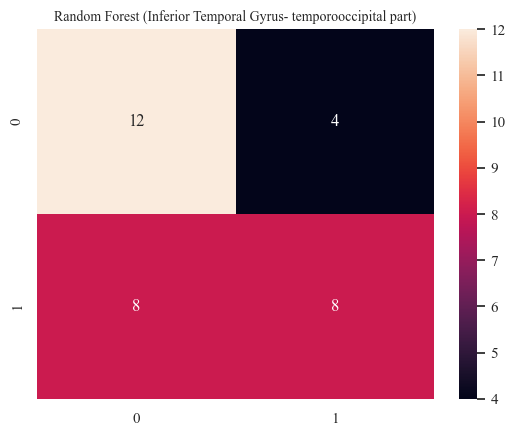

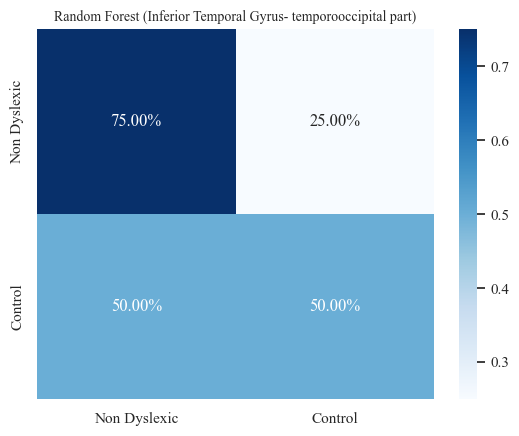

In [25]:
##### Random Forest model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (Random Forest): {rf_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (Random Forest): {rf_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (Random Forest): {rf_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(Rand_Forst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(Rand_Forst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (XGBoost): 100.00%
Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (XGBoost): 71.88%

Classification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (XGBoost):
              precision    recall  f1-score   support

           0       0.68      0.81      0.74        16
           1       0.77      0.62      0.69        16

    accuracy                           0.72        32
   macro avg       0.73      0.72      0.72        32
weighted avg       0.73      0.72      0.72        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (XGBoost): 0.72


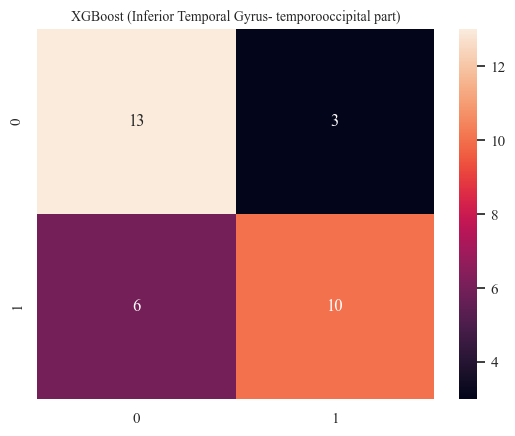

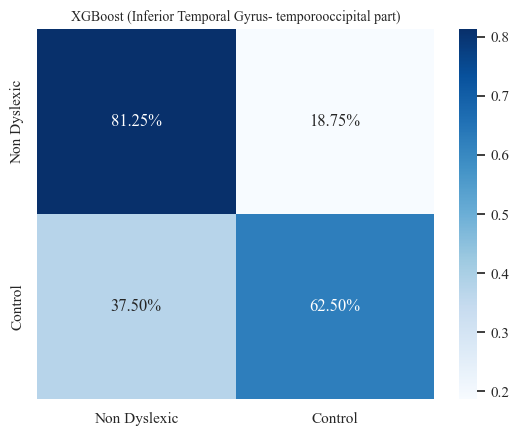

In [26]:
##### XGBoost (Extreme Gradient Boosting) model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus- temporooccipital part (XGBoost): {xgb_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus- temporooccipital part (XGBoost): {xgb_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus- temporooccipital part (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus- temporooccipital part (XGBoost): {xgb_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Inferior Temporal Gyrus- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROI_3(XGBst)_percent.png", dpi=600)
plt.show()

In [27]:
mean3=[]
mean3.append([round(log_mean_prf_ROI3[0][0],2),round(log_mean_prf_ROI3[1][0],2),round(log_mean_prf_ROI3[2][0],2),round(log_mean_test_accuracy_ROI3,2),round(log_mean_roc_ROI3,2)])
mean3.append([round(log_mean_prf_ROI3[0][1],2),round(log_mean_prf_ROI3[1][1],2),round(log_mean_prf_ROI3[2][1],2),'',''])
mean3.append([round(svm_mean_prf_ROI3[0][0],2),round(svm_mean_prf_ROI3[1][0],2),round(svm_mean_prf_ROI3[2][0],2),round(svm_mean_test_accuracy_ROI3,2),round(svm_mean_roc_ROI3,2)])
mean3.append([round(svm_mean_prf_ROI3[0][1],2),round(svm_mean_prf_ROI3[1][1],2),round(svm_mean_prf_ROI3[2][1],2),'',''])
mean3.append([round(knn_mean_prf_ROI3[0][0],2),round(knn_mean_prf_ROI3[1][0],2),round(knn_mean_prf_ROI3[2][0],2),round(knn_mean_test_accuracy_ROI3,2),round(knn_mean_roc_ROI3,2)])
mean3.append([round(knn_mean_prf_ROI3[0][1],2),round(knn_mean_prf_ROI3[1][1],2),round(knn_mean_prf_ROI3[2][1],2),'',''])
mean3.append([round(ann_mean_prf_ROI3[0][0],2),round(ann_mean_prf_ROI3[1][0],2),round(ann_mean_prf_ROI3[2][0],2),round(ann_mean_test_accuracy_ROI3,2),round(ann_mean_roc_ROI3,2)])
mean3.append([round(ann_mean_prf_ROI3[0][1],2),round(ann_mean_prf_ROI3[1][1],2),round(ann_mean_prf_ROI3[2][1],2),'',''])
mean3.append([round(rf_mean_prf_ROI3[0][0],2),round(rf_mean_prf_ROI3[1][0],2),round(rf_mean_prf_ROI3[2][0],2),round(rf_mean_test_accuracy_ROI3,2),round(rf_mean_roc_ROI3,2)])
mean3.append([round(rf_mean_prf_ROI3[0][1],2),round(rf_mean_prf_ROI3[1][1],2),round(rf_mean_prf_ROI3[2][1],2),'',''])
mean3.append([round(xgb_mean_prf_ROI3[0][0],2),round(xgb_mean_prf_ROI3[1][0],2),round(xgb_mean_prf_ROI3[2][0],2),round(xgb_mean_test_accuracy_ROI3,2),round(xgb_mean_roc_ROI3,2)])
mean3.append([round(xgb_mean_prf_ROI3[0][1],2),round(xgb_mean_prf_ROI3[1][1],2),round(xgb_mean_prf_ROI3[2][1],2),'',''])

df2 = pd.DataFrame(mean3,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
#df2=df2.style.set_sticky(axis="index")
df2.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
df2.style.set_caption("Table ROI_3 (Mean) Inferior Temporal Gyrus- temporooccipital part")
display(df2)
df2.to_excel('../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Table_Mean_ROI_3_Inferior_Temporal_Gyrus.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.45    0.62      0.53     0.44   
                           Control            0.40    0.25      0.31            
Support Vector Machine     Non-Dyslexic       0.56    0.88      0.68     0.59   
                           Control            0.71    0.31      0.43            
k-nearest neighbors        Non-Dyslexic       0.54    0.94      0.68     0.56   
                           Control            0.75    0.19      0.30            
Artificial Neural Networks Non-Dyslexic       0.52    0.75      0.62     0.53   
                           Control            0.56    0.31      0.40            
Random Forest              Non-Dyslexic       0.60    0.75      0.67     0.62   
                           Control            0.67    0.50      0.57            
XGBoost                    Non-Dyslexic       0.68    0.81      0.74     0.72   
                           Control            0.77    0.62      0.69            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.44  
                           Control               
Support Vector Machine     Non-Dyslexic    0.59  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.56  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.53  
                           Control               
Random Forest              Non-Dyslexic    0.62  
                           Control               
XGBoost                    Non-Dyslexic    0.72  
                           Control

## Combining ROIs  1 and 2 **(MEAN)**:- Inferior Temporal Gyrus- 1) Anterior division & 2) Posterior division 
#### Combining them into a single dataset to perform the experiments.

In [28]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd1 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
cmd2 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_posterior_division.npz")
ndmd2 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)
print()
####Bringing the data to equal shape and size
control_m_d1=[]
non_dyslexic_m_d1=[]
for i in range(len(control_mean_data1)):
    control_m_d1.insert(i, np.pad(control_mean_data1[i], (0, control_mean_data2[0].shape[0]-control_mean_data1[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data1)):
    non_dyslexic_m_d1.insert(i, np.pad(non_dyslexic_mean_data1[i], (0, non_dyslexic_mean_data2[0].shape[0]-non_dyslexic_mean_data1[0].shape[0]), 'mean'))
print(control_m_d1[0].shape)
print(non_dyslexic_m_d1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)

80
80
80
80
(1665,)
(1665,)
(4262,)
(4262,)

(4262,)
(4262,)
(4262,)
(4262,)


In [29]:
# Combine the aggregated data from both groups
ll1=len(control_m_d1)+len(control_mean_data2)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_mean_data2)
X = np.vstack([control_m_d1,control_mean_data2 ,non_dyslexic_m_d1,non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)
##############################################################################################
##################### "If you want to save the Resultant Dataset" ############################
#np.savez("Data_Mask-Mean/Inferior_Frontal_Gyrus_Mean_Combine_1_2.npz", X=X, y=y)
##################### "If you want to save the Resultant Dataset" ############################
##############################################################################################

(320, 4262)
(320,)


Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Logistic regression): 100.00%
Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Logistic regression): 51.56%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Logistic regression):
              precision    recall  f1-score   support

           0       0.52      0.50      0.51        32
           1       0.52      0.53      0.52        32

    accuracy                           0.52        64
   macro avg       0.52      0.52      0.52        64
weighted avg       0.52      0.52      0.52        64


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Logistic Regression): 0.52


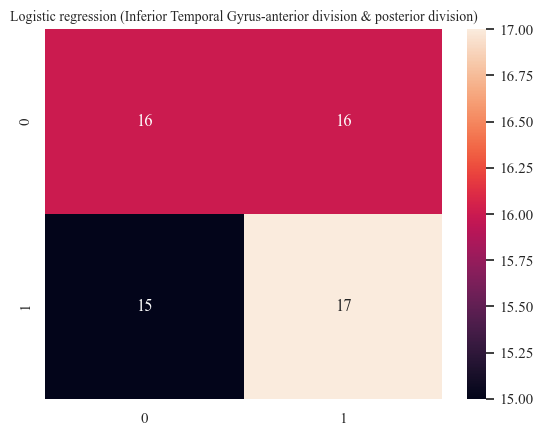

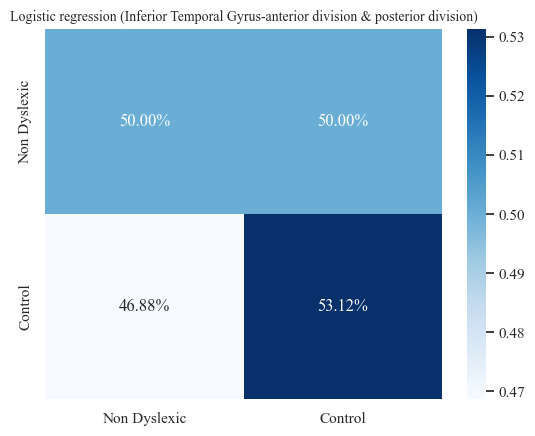

In [30]:
#Logistic regression
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Logistic regression): {log_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Logistic regression): {log_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Logistic Regression): {log_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Support Vector Machine): 63.67%
Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Support Vector Machine): 53.12%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Support Vector Machine):
              precision    recall  f1-score   support

           0       0.52      0.91      0.66        32
           1       0.62      0.16      0.25        32

    accuracy                           0.53        64
   macro avg       0.57      0.53      0.45        64
weighted avg       0.57      0.53      0.45        64


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Support Vector Machine): 0.53


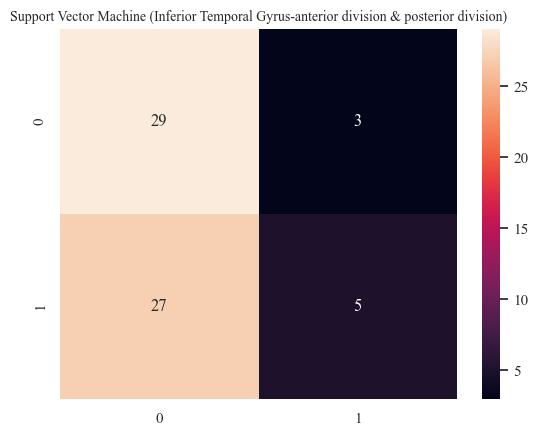

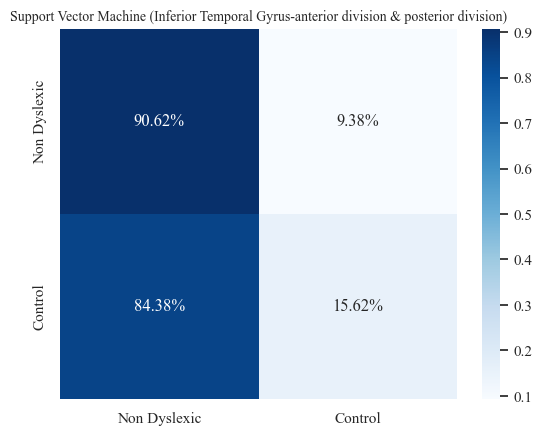

In [31]:
#Support Vector Machine
# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Support Vector Machine): {svm_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Support Vector Machine): {svm_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Support Vector Machine): {svm_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(svm)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(svm)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(k-nearest neighbors): 66.02%
Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(k-nearest neighbors): 54.69%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.53      0.88      0.66        32
           1       0.64      0.22      0.33        32

    accuracy                           0.55        64
   macro avg       0.58      0.55      0.49        64
weighted avg       0.58      0.55      0.49        64


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(k-nearest neighbors): 0.55


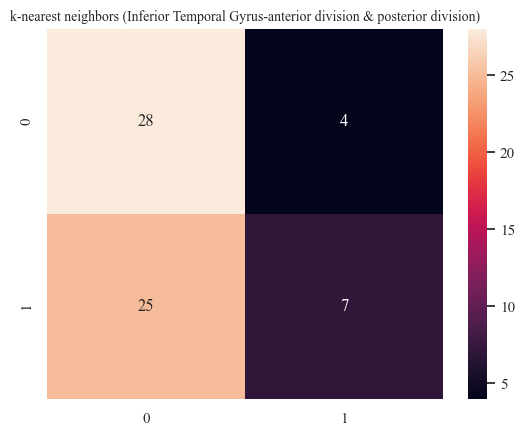

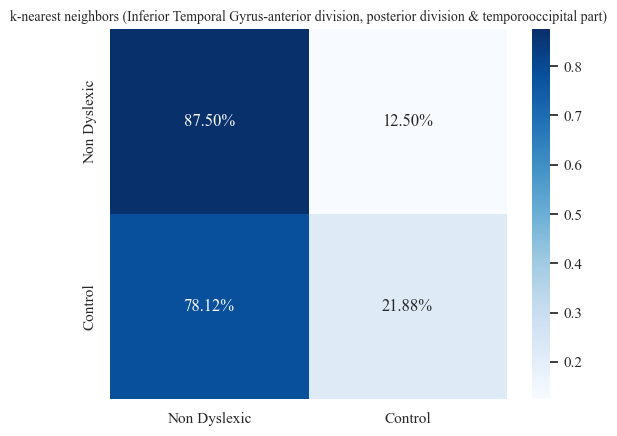

In [32]:
# k-nearest neighbors

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(k-nearest neighbors): {knn_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(k-nearest neighbors): {knn_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(k-nearest neighbors): {knn_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(KNN)_percent.png", dpi=600)
plt.show()

In [33]:
print("Total Dataset:- ",X.shape)
print("Total Labels:- ",y.shape)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])


Total Dataset:-  (320, 4262)
Total Labels:-  (320,)
Total Training set:-  Dataset:- (256, 4262) Label:- (256,)
Total Testing set:-  Dataset:- (64, 4262) Label:- (64,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 512)                 │       2,182,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,258,689 (8.62 MB)

 Trainable params: 2,258,689 (8.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5281 - loss: 0.7146
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7625 - loss: 0.5208
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7906 - loss: 0.4497
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8401 - loss: 0.3791
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9156 - loss: 0.2907
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8896 - loss: 0.2410
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9224 - loss: 0.1762
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9411 - loss: 0.1329
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9484 - loss: 0.1015
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9083 - loss: 0.1551
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9651 - loss: 0.1084
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9385 - loss: 0.0943
E

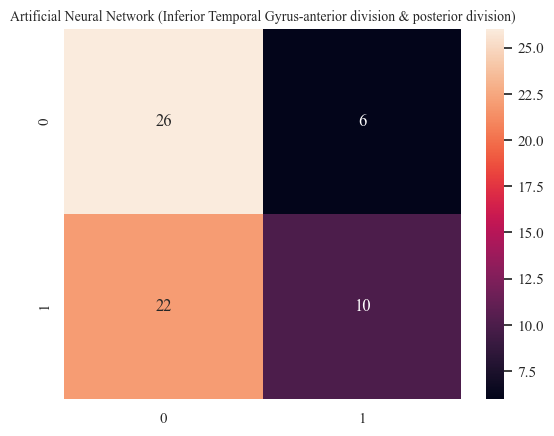

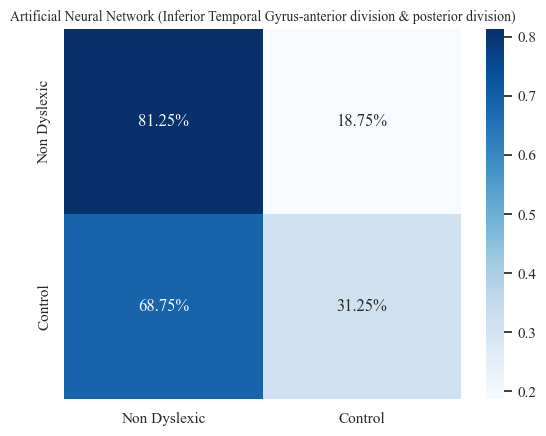

In [34]:
# Artificial Neural Network
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
#model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
#model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
# Calculate training and testing accuracy
ann_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Artificial Neural Network): {ann_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Artificial Neural Network): {ann_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Artificial Neural Network): {ann_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Random Forest): 100.00%
Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Random Forest): 62.50%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Random Forest):
              precision    recall  f1-score   support

           0       0.62      0.62      0.62        32
           1       0.62      0.62      0.62        32

    accuracy                           0.62        64
   macro avg       0.62      0.62      0.62        64
weighted avg       0.62      0.62      0.62        64


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Random Forest): 0.62


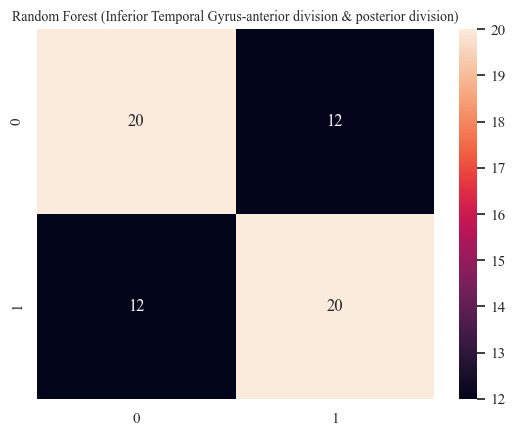

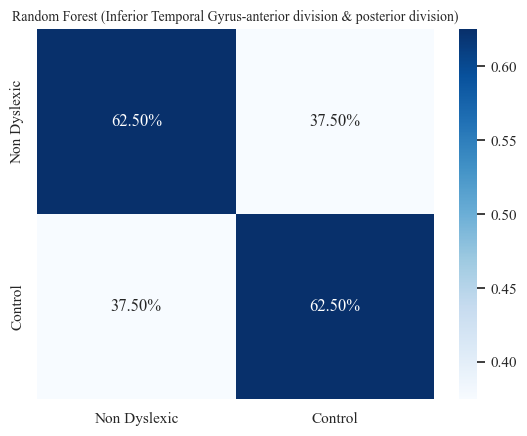

In [35]:
#Random Forest Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Random Forest): {rf_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(Random Forest): {rf_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(Random Forest): {rf_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(Rand_Frst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(Rand_Frst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(XGBoost): 100.00%
Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(XGBoost): 62.50%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(XGBoost):
              precision    recall  f1-score   support

           0       0.63      0.59      0.61        32
           1       0.62      0.66      0.64        32

    accuracy                           0.62        64
   macro avg       0.63      0.62      0.62        64
weighted avg       0.63      0.62      0.62        64


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(XGBoost): 0.62


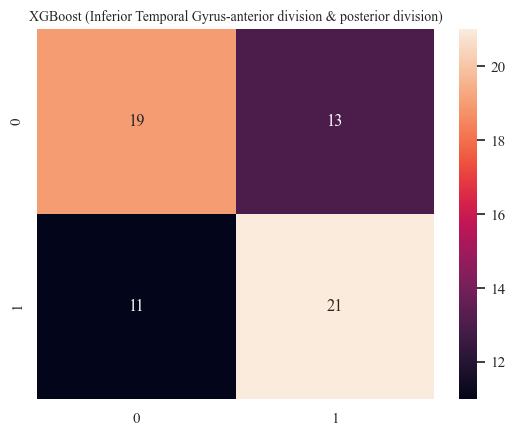

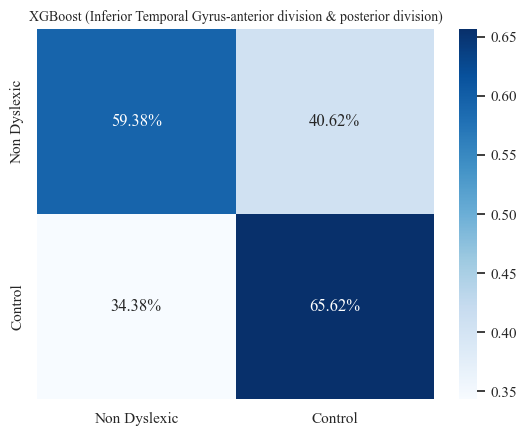

In [36]:
# XGBoost (Extreme Gradient Boosting) Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(XGBoost): {xgb_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division & posterior division(XGBoost): {xgb_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & posterior division(XGBoost): {xgb_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Inferior Temporal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_2(XGBst)_percent.png", dpi=600)
plt.show()

#### <b> Display results in dataframe tabular format (Comparison of all the models)</b>

In [37]:
mean_all=[]
mean_all.append([round(log_mean_prf_ROIs_1_2[0][0],2),round(log_mean_prf_ROIs_1_2[1][0],2),round(log_mean_prf_ROIs_1_2[2][0],2),round(log_mean_test_accuracy_ROIs_1_2,2),round(log_mean_roc_ROIs_1_2,2)])
mean_all.append([round(log_mean_prf_ROIs_1_2[0][1],2),round(log_mean_prf_ROIs_1_2[1][1],2),round(log_mean_prf_ROIs_1_2[2][1],2),'',''])
mean_all.append([round(svm_mean_prf_ROIs_1_2[0][0],2),round(svm_mean_prf_ROIs_1_2[1][0],2),round(svm_mean_prf_ROIs_1_2[2][0],2),round(svm_mean_test_accuracy_ROIs_1_2,2),round(svm_mean_roc_ROIs_1_2,2)])
mean_all.append([round(svm_mean_prf_ROIs_1_2[0][1],2),round(svm_mean_prf_ROIs_1_2[1][1],2),round(svm_mean_prf_ROIs_1_2[2][1],2),'',''])
mean_all.append([round(knn_mean_prf_ROIs_1_2[0][0],2),round(knn_mean_prf_ROIs_1_2[1][0],2),round(knn_mean_prf_ROIs_1_2[2][0],2),round(knn_mean_test_accuracy_ROIs_1_2,2),round(knn_mean_roc_ROIs_1_2,2)])
mean_all.append([round(knn_mean_prf_ROIs_1_2[0][1],2),round(knn_mean_prf_ROIs_1_2[1][1],2),round(knn_mean_prf_ROIs_1_2[2][1],2),'',''])
mean_all.append([round(ann_mean_prf_ROIs_1_2[0][0],2),round(ann_mean_prf_ROIs_1_2[1][0],2),round(ann_mean_prf_ROIs_1_2[2][0],2),round(ann_mean_test_accuracy_ROIs_1_2,2),round(ann_mean_roc_ROIs_1_2,2)])
mean_all.append([round(ann_mean_prf_ROIs_1_2[0][1],2),round(ann_mean_prf_ROIs_1_2[1][1],2),round(ann_mean_prf_ROIs_1_2[2][1],2),'',''])
mean_all.append([round(rf_mean_prf_ROIs_1_2[0][0],2),round(rf_mean_prf_ROIs_1_2[1][0],2),round(rf_mean_prf_ROIs_1_2[2][0],2),round(rf_mean_test_accuracy_ROIs_1_2,2),round(rf_mean_roc_ROIs_1_2,2)])
mean_all.append([round(rf_mean_prf_ROIs_1_2[0][1],2),round(rf_mean_prf_ROIs_1_2[1][1],2),round(rf_mean_prf_ROIs_1_2[2][1],2),'',''])
mean_all.append([round(xgb_mean_prf_ROIs_1_2[0][0],2),round(xgb_mean_prf_ROIs_1_2[1][0],2),round(xgb_mean_prf_ROIs_1_2[2][0],2),round(xgb_mean_test_accuracy_ROIs_1_2,2),round(xgb_mean_roc_ROIs_1_2,2)])
mean_all.append([round(xgb_mean_prf_ROIs_1_2[0][1],2),round(xgb_mean_prf_ROIs_1_2[1][1],2),round(xgb_mean_prf_ROIs_1_2[2][1],2),'',''])

df3 = pd.DataFrame(mean_all,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
df3.style\
.set_caption("Comparison Table: Inferior Temporal Gyrus-anterior division & posterior division(Mean)")\
.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}])
display(df3)
df3.to_excel('../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Table_Mean_ROIs_1_2_Inferior_Temporal_Gyrus.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.52    0.50      0.51     0.52   
                           Control            0.52    0.53      0.52            
Support Vector Machine     Non-Dyslexic       0.52    0.91      0.66     0.53   
                           Control            0.62    0.16      0.25            
k-nearest neighbors        Non-Dyslexic       0.53    0.88      0.66     0.55   
                           Control            0.64    0.22      0.33            
Artificial Neural Networks Non-Dyslexic       0.54    0.81      0.65     0.56   
                           Control            0.62    0.31      0.42            
Random Forest              Non-Dyslexic       0.62    0.62      0.62     0.62   
                           Control            0.62    0.62      0.62            
XGBoost                    Non-Dyslexic       0.63    0.59      0.61     0.62   
                           Control            0.62    0.66      0.64            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.52  
                           Control               
Support Vector Machine     Non-Dyslexic    0.53  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.55  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.56  
                           Control               
Random Forest              Non-Dyslexic    0.62  
                           Control               
XGBoost                    Non-Dyslexic    0.62  
                           Control

## Combining all the ROIs **(MEAN)**:- Inferior Temporal Gyrus- 1) Anterior division, 2) Posterior division & 3) Temporooccipital part .
#### Combining them into a single dataset to perform the experiments.

In [38]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd1 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
cmd2 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_posterior_division.npz")
ndmd2 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
cmd3 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_temporooccipital_part.npz")
ndmd3 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data3 = cmd3["control_mean_data3"]
non_dyslexic_mean_data3=ndmd3["non_dyslexic_mean_data3"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(len(control_mean_data3))
print(len(non_dyslexic_mean_data3))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)
print(control_mean_data3[0].shape)
print(non_dyslexic_mean_data3[0].shape)
#print(control_mean_data1[79][2376])
print()
####Bringing the data to equal shape and size
control_m_d1=[]
non_dyslexic_m_d1=[]
for i in range(len(control_mean_data1)):
    control_m_d1.insert(i, np.pad(control_mean_data1[i], (0, control_mean_data3[0].shape[0]-control_mean_data1[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data1)):
    non_dyslexic_m_d1.insert(i, np.pad(non_dyslexic_mean_data1[i], (0, non_dyslexic_mean_data3[0].shape[0]-non_dyslexic_mean_data1[0].shape[0]), 'mean'))
control_m_d2=[]
non_dyslexic_m_d2=[]
for i in range(len(control_mean_data2)):
    control_m_d2.insert(i, np.pad(control_mean_data2[i], (0, control_mean_data3[0].shape[0]-control_mean_data2[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data2)):
    non_dyslexic_m_d2.insert(i, np.pad(non_dyslexic_mean_data2[i], (0, non_dyslexic_mean_data3[0].shape[0]-non_dyslexic_mean_data2[0].shape[0]), 'mean'))
print(control_m_d1[0].shape)
print(non_dyslexic_m_d1[0].shape)
print(control_m_d2[0].shape)
print(non_dyslexic_m_d2[0].shape)
print(control_mean_data3[0].shape)
print(non_dyslexic_mean_data3[0].shape)


80
80
80
80
80
80
(1665,)
(1665,)
(4262,)
(4262,)
(4819,)
(4819,)

(4819,)
(4819,)
(4819,)
(4819,)
(4819,)
(4819,)


In [39]:
# Combine the aggregated data from both groups
ll1=len(control_m_d1)+len(control_m_d2)+len(control_mean_data3)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_m_d2)+len(non_dyslexic_mean_data3)
X = np.vstack([control_m_d1,control_m_d2,control_mean_data3 ,non_dyslexic_m_d1,non_dyslexic_m_d2,non_dyslexic_mean_data3])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)
##############################################################################################
##################### "If you want to save the Resultant Dataset" ############################
#np.savez("Data_Mask-Mean/Inferior_Frontal_Gyrus_Mean_Combine.npz", X=X, y=y)
##################### "If you want to save the Resultant Dataset" ############################
##############################################################################################

(480, 4819)
(480,)


Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Logistic regression): 100.00%
Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Logistic regression): 50.00%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Logistic regression):
              precision    recall  f1-score   support

           0       0.51      0.47      0.49        49
           1       0.49      0.53      0.51        47

    accuracy                           0.50        96
   macro avg       0.50      0.50      0.50        96
weighted avg       0.50      0.50      0.50        96


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Logistic Regression): 0.50


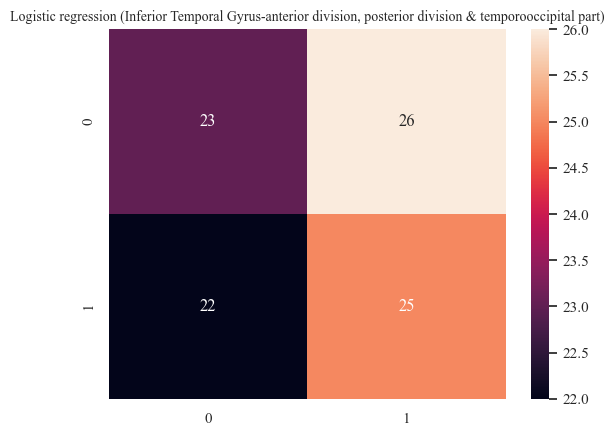

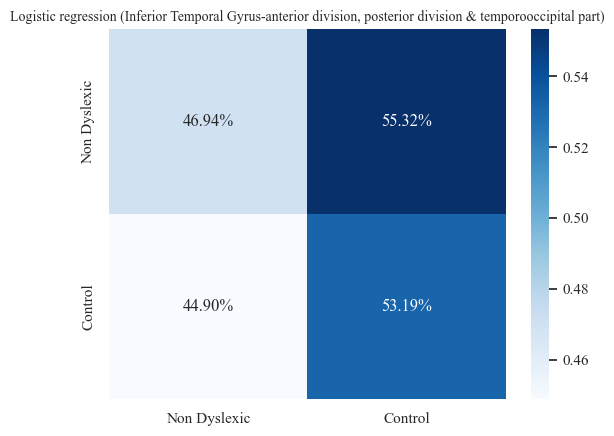

In [40]:
#Logistic regression
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Logistic regression): {log_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Logistic regression): {log_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_All_ROIs[0][0]:.2f}, Precision 1:- {log_mean_prf_All_ROIs[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_All_ROIs[1][0]:.2f}, Recall 1:- {log_mean_prf_All_ROIs[1][1]:.2f}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Logistic Regression): {log_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Support Vector Machine): 67.71%
Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part(Support Vector Machine): 51.04%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.51      0.82      0.63        49
           1       0.50      0.19      0.28        47

    accuracy                           0.51        96
   macro avg       0.51      0.50      0.45        96
weighted avg       0.51      0.51      0.46        96


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Support Vector Machine): 0.50


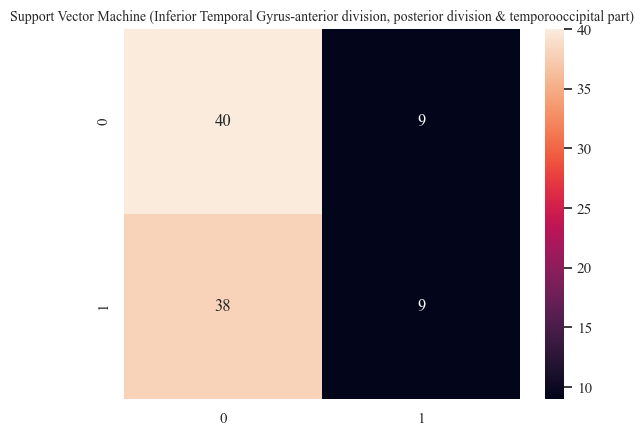

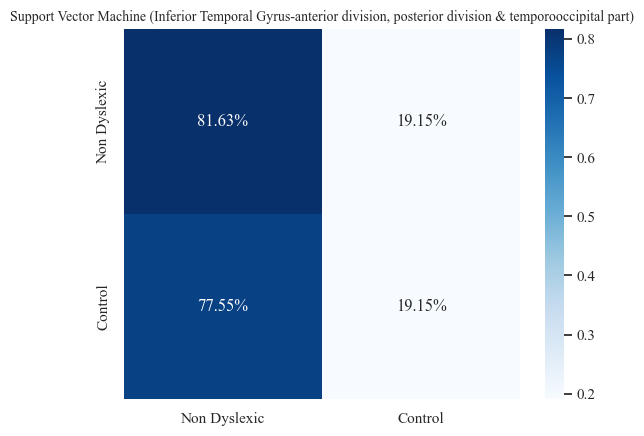

In [41]:
#Support Vector Machine
# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Support Vector Machine): {svm_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part(Support Vector Machine): {svm_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Support Vector Machine): {svm_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(svm)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(svm)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (k-nearest neighbors): 82.29%
Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (k-nearest neighbors): 51.04%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.53      0.33      0.41        49
           1       0.50      0.70      0.58        47

    accuracy                           0.51        96
   macro avg       0.52      0.51      0.49        96
weighted avg       0.52      0.51      0.49        96


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (k-nearest neighbors): 0.51


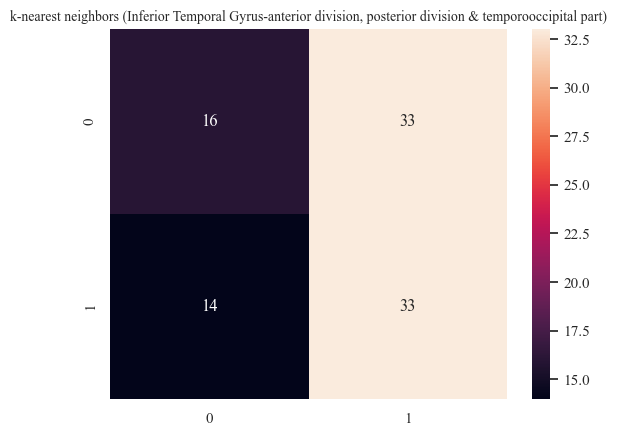

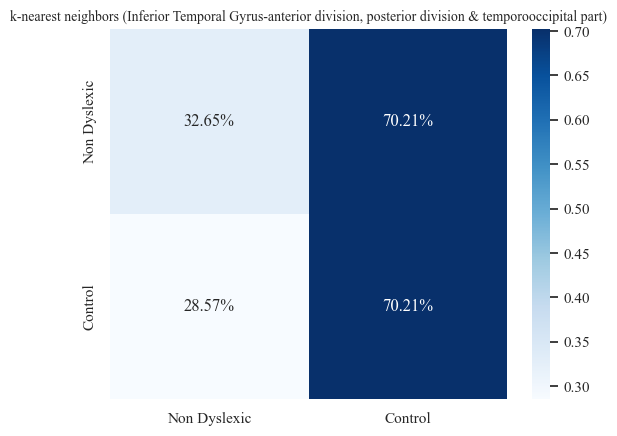

In [42]:
# k-nearest neighbors

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (k-nearest neighbors): {knn_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (k-nearest neighbors): {knn_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (k-nearest neighbors): {knn_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(KNN)_percent.png", dpi=600)
plt.show()

In [43]:
print("Total Dataset:- ",X.shape)
print("Total Labels:- ",y.shape)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])


Total Dataset:-  (480, 4819)
Total Labels:-  (480,)
Total Training set:-  Dataset:- (384, 4819) Label:- (384,)
Total Testing set:-  Dataset:- (96, 4819) Label:- (96,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                     │ (None, 512)                 │       2,467,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,543,873 (9.70 MB)

 Trainable params: 2,543,873 (9.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4714 - loss: 0.8287
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5843 - loss: 0.6753
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6333 - loss: 0.7160
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6297 - loss: 0.6333
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6585 - loss: 0.6305
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7068 - loss: 0.5223
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6956 - loss: 0.5475
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7690 - loss: 0.4533
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8188 - loss: 0.4501
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8157 - loss: 0.4572
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8200 - loss: 0.3734
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8622 - loss: 0.3459
E

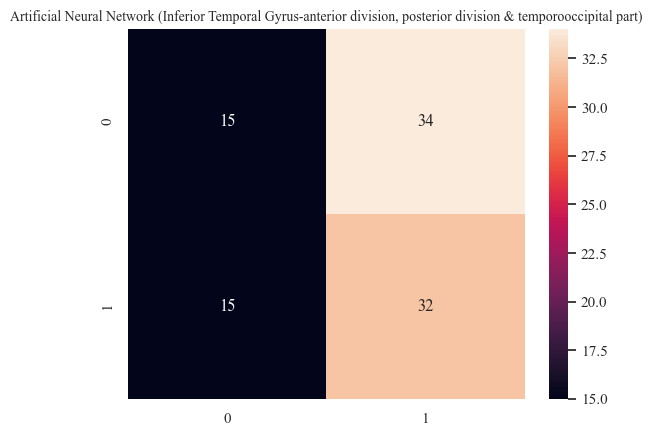

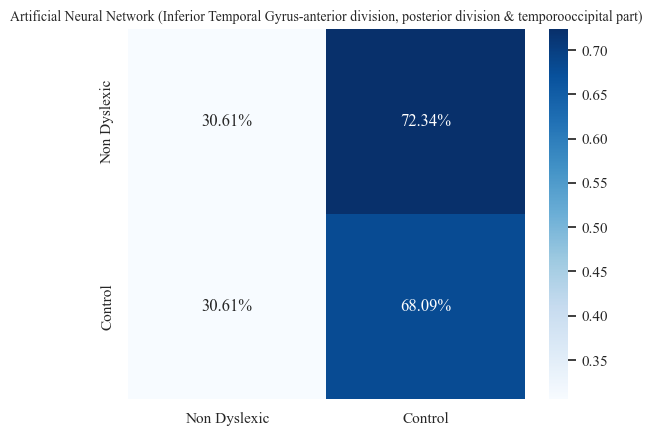

In [44]:
# Artificial Neural Network
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
# Calculate training and testing accuracy
ann_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Artificial Neural Network): {ann_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Artificial Neural Network): {ann_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Artificial Neural Network): {ann_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Random Forest): 100.00%
Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Random Forest): 47.92%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Random Forest):
              precision    recall  f1-score   support

           0       0.49      0.57      0.53        49
           1       0.46      0.38      0.42        47

    accuracy                           0.48        96
   macro avg       0.48      0.48      0.47        96
weighted avg       0.48      0.48      0.47        96


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Random Forest): 0.48


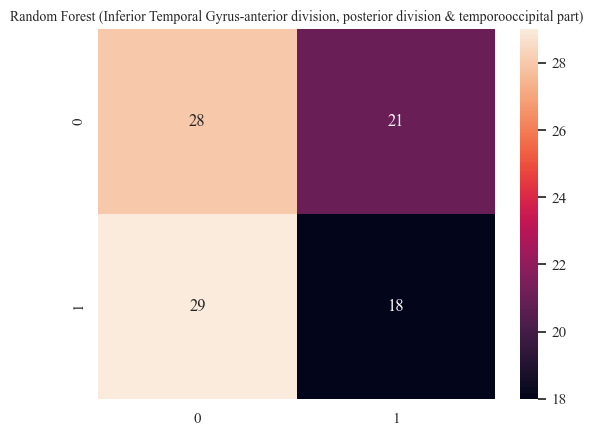

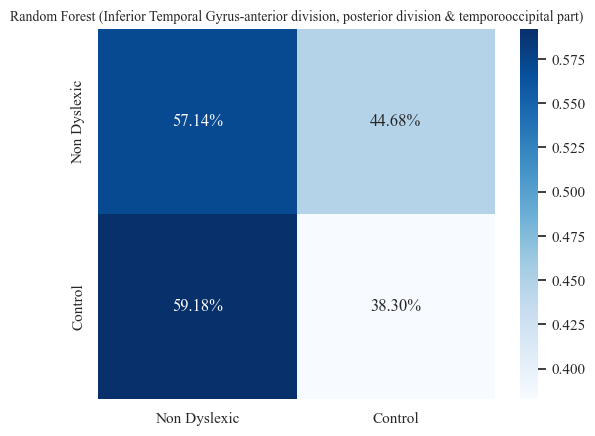

In [45]:
# Random Forest Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Random Forest): {rf_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Random Forest): {rf_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (Random Forest): {rf_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(Rand_Frst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(Rand_Frst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (XGBoost): 100.00%
Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (XGBoost): 53.12%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (XGBoost):
              precision    recall  f1-score   support

           0       0.55      0.49      0.52        49
           1       0.52      0.57      0.55        47

    accuracy                           0.53        96
   macro avg       0.53      0.53      0.53        96
weighted avg       0.53      0.53      0.53        96


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (XGBoost): 0.53


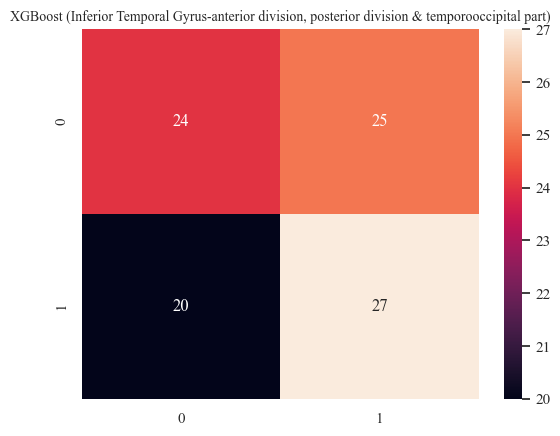

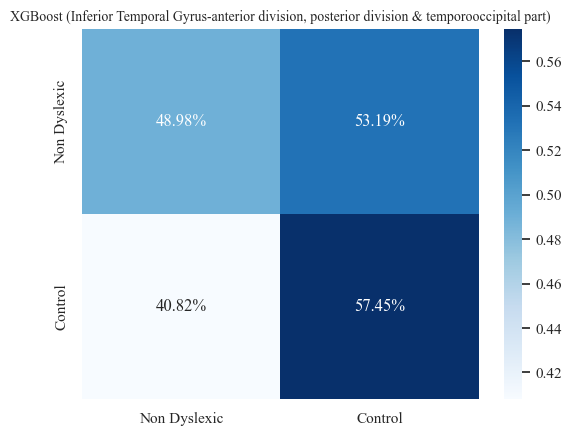

In [46]:
# XGBoost (Extreme Gradient Boosting) Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (XGBoost): {xgb_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (XGBoost): {xgb_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_All_ROIs[0][0]:.2f}, Precision 1:- {log_mean_prf_All_ROIs[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_All_ROIs[1][0]:.2f}, Recall 1:- {log_mean_prf_All_ROIs[1][1]:.2f}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part (XGBoost): {xgb_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_All_ROIs(XGBst)_percent.png", dpi=600)
plt.show()

#### <b> Display results in dataframe tabular format (Comparison of all the models)</b>

In [47]:
mean_all=[]
mean_all.append([round(log_mean_prf_All_ROIs[0][0],2),round(log_mean_prf_All_ROIs[1][0],2),round(log_mean_prf_All_ROIs[2][0],2),round(log_mean_test_accuracy_All_ROIs,2),round(log_mean_roc_All_ROIs,2)])
mean_all.append([round(log_mean_prf_All_ROIs[0][1],2),round(log_mean_prf_All_ROIs[1][1],2),round(log_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(svm_mean_prf_All_ROIs[0][0],2),round(svm_mean_prf_All_ROIs[1][0],2),round(svm_mean_prf_All_ROIs[2][0],2),round(svm_mean_test_accuracy_All_ROIs,2),round(svm_mean_roc_All_ROIs,2)])
mean_all.append([round(svm_mean_prf_All_ROIs[0][1],2),round(svm_mean_prf_All_ROIs[1][1],2),round(svm_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(knn_mean_prf_All_ROIs[0][0],2),round(knn_mean_prf_All_ROIs[1][0],2),round(knn_mean_prf_All_ROIs[2][0],2),round(knn_mean_test_accuracy_All_ROIs,2),round(knn_mean_roc_All_ROIs,2)])
mean_all.append([round(knn_mean_prf_All_ROIs[0][1],2),round(knn_mean_prf_All_ROIs[1][1],2),round(knn_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(ann_mean_prf_All_ROIs[0][0],2),round(ann_mean_prf_All_ROIs[1][0],2),round(ann_mean_prf_All_ROIs[2][0],2),round(ann_mean_test_accuracy_All_ROIs,2),round(ann_mean_roc_All_ROIs,2)])
mean_all.append([round(ann_mean_prf_All_ROIs[0][1],2),round(ann_mean_prf_All_ROIs[1][1],2),round(ann_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(rf_mean_prf_All_ROIs[0][0],2),round(rf_mean_prf_All_ROIs[1][0],2),round(rf_mean_prf_All_ROIs[2][0],2),round(rf_mean_test_accuracy_All_ROIs,2),round(rf_mean_roc_All_ROIs,2)])
mean_all.append([round(rf_mean_prf_All_ROIs[0][1],2),round(rf_mean_prf_All_ROIs[1][1],2),round(rf_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][0],2),round(xgb_mean_prf_All_ROIs[1][0],2),round(xgb_mean_prf_All_ROIs[2][0],2),round(xgb_mean_test_accuracy_All_ROIs,2),round(xgb_mean_roc_All_ROIs,2)])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][1],2),round(xgb_mean_prf_All_ROIs[1][1],2),round(xgb_mean_prf_All_ROIs[2][1],2),'',''])

df3 = pd.DataFrame(mean_all,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
df3.style\
.set_caption("Comparison Table: Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part [All ROIs (Mean)]")\
.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}])
display(df3)
df3.to_excel('../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Table_Mean_All_ROIs_Inferior_Temporal_Gyrus.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.51    0.47      0.49      0.5   
                           Control            0.49    0.53      0.51            
Support Vector Machine     Non-Dyslexic       0.51    0.82      0.63     0.51   
                           Control            0.50    0.19      0.28            
k-nearest neighbors        Non-Dyslexic       0.53    0.33      0.41     0.51   
                           Control            0.50    0.70      0.58            
Artificial Neural Networks Non-Dyslexic       0.50    0.31      0.38     0.49   
                           Control            0.48    0.68      0.57            
Random Forest              Non-Dyslexic       0.49    0.57      0.53     0.48   
                           Control            0.46    0.38      0.42            
XGBoost                    Non-Dyslexic       0.55    0.49      0.52     0.53   
                           Control            0.52    0.57      0.55            

                                        roc_auc  
Logistic Regression        Non-Dyslexic     0.5  
                           Control               
Support Vector Machine     Non-Dyslexic     0.5  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.51  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.49  
                           Control               
Random Forest              Non-Dyslexic    0.48  
                           Control               
XGBoost                    Non-Dyslexic    0.53  
                           Control

## Combining all the ROIs **(MEAN)**:- Inferior Temporal Gyrus- 1) Anterior division & 3) Temporooccipital part .
#### Combining them into a single dataset <i>(vertically)</i> to perform the experiments.
<b>(Experiment using only XGBoost)</b>

In [48]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd1 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]

cmd3 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_temporooccipital_part.npz")
ndmd3 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data3 = cmd3["control_mean_data3"]
non_dyslexic_mean_data3=ndmd3["non_dyslexic_mean_data3"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(len(control_mean_data3))
print(len(non_dyslexic_mean_data3))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
print(control_mean_data3[0].shape)
print(non_dyslexic_mean_data3[0].shape)
#print(control_mean_data1[79][2376])
print()
####Bringing the data to equal shape and size
control_m_d1=[]
non_dyslexic_m_d1=[]
for i in range(len(control_mean_data1)):
    control_m_d1.insert(i, np.pad(control_mean_data1[i], (0, control_mean_data3[0].shape[0]-control_mean_data1[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data1)):
    non_dyslexic_m_d1.insert(i, np.pad(non_dyslexic_mean_data1[i], (0, non_dyslexic_mean_data3[0].shape[0]-non_dyslexic_mean_data1[0].shape[0]), 'mean'))
print(control_m_d1[0].shape)
print(non_dyslexic_m_d1[0].shape)
print(control_mean_data3[0].shape)
print(non_dyslexic_mean_data3[0].shape)


80
80
80
80
(1665,)
(1665,)
(4819,)
(4819,)

(4819,)
(4819,)
(4819,)
(4819,)


In [49]:
# Combine the aggregated data from both groups
ll1=len(control_m_d1)+len(control_mean_data3)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_mean_data3)
X = np.vstack([control_m_d1,control_mean_data3 ,non_dyslexic_m_d1,non_dyslexic_mean_data3])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)

(320, 4819)
(320,)


Training Accuracy on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): 100.00%
Testing Accuracy on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): 56.25%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost):
              precision    recall  f1-score   support

           0       0.57      0.53      0.55        32
           1       0.56      0.59      0.58        32

    accuracy                           0.56        64
   macro avg       0.56      0.56      0.56        64
weighted avg       0.56      0.56      0.56        64


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): 0.56


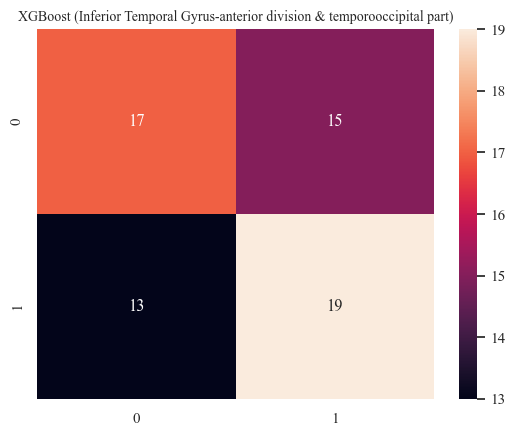

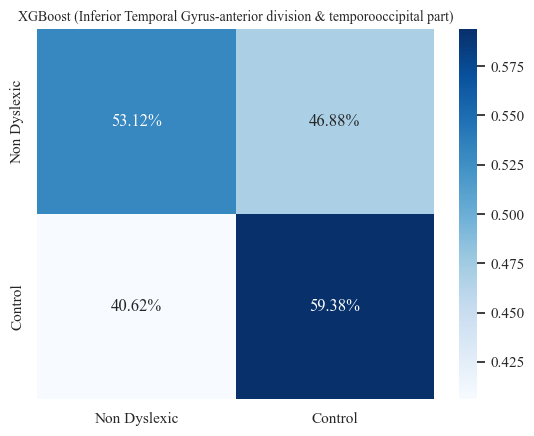

In [50]:
# XGBoost (Extreme Gradient Boosting) Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROIs_1_3 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROIs_1_3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): {xgb_mean_train_accuracy_ROIs_1_3 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): {xgb_mean_test_accuracy_ROIs_1_3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROIs_1_3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROIs_1_3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): {xgb_mean_roc_ROIs_1_3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Inferior Temporal Gyrus-anterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_3(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Inferior Temporal Gyrus-anterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_3(XGBst)_percent.png", dpi=600)
plt.show()

##### Combining the dataset (ROI 1 & 3) <i>horizantally</i>

In [51]:
arr1 = np.array([[1, 2],
                   [3, 4],
                   [5, 6]])

arr2 = np.array([[7, 8, 9],
                   [10, 11, 12],
                   [13, 14, 15]])

arr3=np.concatenate((arr1, arr2), axis=1)

display(arr3)

array([[ 1,  2,  7,  8,  9],
       [ 3,  4, 10, 11, 12],
       [ 5,  6, 13, 14, 15]])

In [52]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd1 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]

cmd3 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_temporooccipital_part.npz")
ndmd3 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data3 = cmd3["control_mean_data3"]
non_dyslexic_mean_data3=ndmd3["non_dyslexic_mean_data3"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(len(control_mean_data3))
print(len(non_dyslexic_mean_data3))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
print(control_mean_data3[0].shape)
print(non_dyslexic_mean_data3[0].shape)
#print(control_mean_data1[79][2376])
print()
####Bringing the data to equal shape and size
#control_m_d=[]
#non_dyslexic_m_d=[]
control_m_d=np.concatenate((control_mean_data1, control_mean_data3), axis=1)
non_dyslexic_m_d=np.concatenate((non_dyslexic_mean_data1, non_dyslexic_mean_data3), axis=1)
print(len(control_m_d))
print(len(non_dyslexic_m_d))
print(control_m_d[0].shape)
print(non_dyslexic_m_d[0].shape)

# Combine the aggregated data from both groups
ll1=len(control_m_d)
ll2=len(non_dyslexic_m_d)
X = np.vstack([control_m_d ,non_dyslexic_m_d])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)

80
80
80
80
(1665,)
(1665,)
(4819,)
(4819,)

80
80
(6484,)
(6484,)
(160, 6484)
(160,)


Training Accuracy on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): 100.00%
Testing Accuracy on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): 65.62%

Classification Report for Testing Data on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost):
              precision    recall  f1-score   support

           0       0.63      0.75      0.69        16
           1       0.69      0.56      0.62        16

    accuracy                           0.66        32
   macro avg       0.66      0.66      0.65        32
weighted avg       0.66      0.66      0.65        32


ROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): 0.66


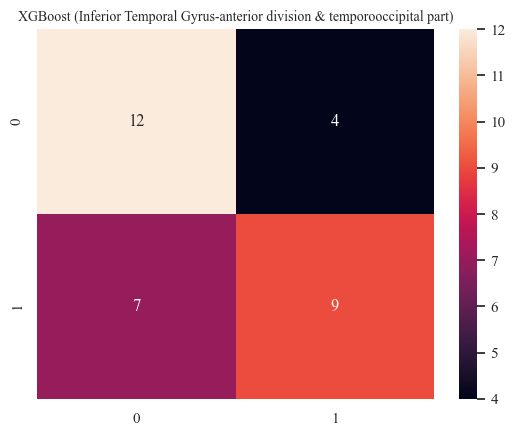

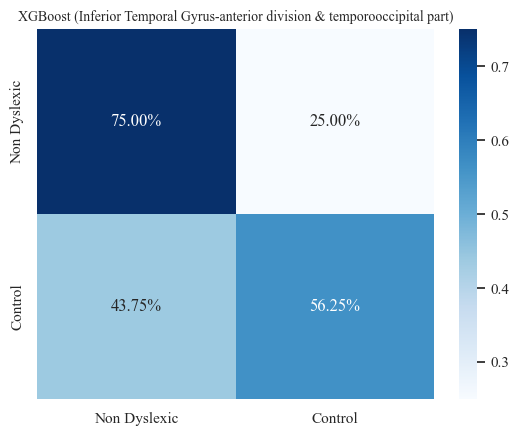

In [53]:
# XGBoost (Extreme Gradient Boosting) Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROIs_1_3 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROIs_1_3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): {xgb_mean_train_accuracy_ROIs_1_3 * 100:.2f}%")
print(f"Testing Accuracy on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): {xgb_mean_test_accuracy_ROIs_1_3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROIs_1_3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROIs_1_3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Inferior Temporal Gyrus-anterior division & temporooccipital part (XGBoost): {xgb_mean_roc_ROIs_1_3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Inferior Temporal Gyrus-anterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_3_V(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Inferior Temporal Gyrus-anterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/4-Inferior_Temporal_Gyrus/Output_Mean/Inferior_Temporal_Gyrus_ROIs_1_3_V(XGBst)_percent.png", dpi=600)
plt.show()